<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/12_Qubit_Flux_Tunable_Processor_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 12-Qubit Flux-Tunable Xmon Processor Layout

This notebook uses the same headless Quantum Metal, PHIDL, and GDSTK pattern as the successful six-Xmon layout. The processor is organized as a two-column array around a central feedline with Quantum Metal meandered readout resonators and side-routed flux-bias fanout lines.

In [ ]:
"""
This script installs and patches a headless Quantum Metal stack for a SQUADDS-style 12-qubit flux-tunable processor layout workflow in Google Colab.

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)
"""

import os
import subprocess
import sys
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FORCE_CLEAN_INSTALL: Final[bool] = False
RESTART_AFTER_INSTALL: Final[bool] = True
INSTALL_SENTINEL: Final[Path] = Path("/content/.qm_12q_flux_squadds_style_stack")

QT_QPA_PLATFORM: Final[str] = "offscreen"
MPLBACKEND: Final[str] = "Agg"

BINARY_FOUNDATION_PACKAGES: Final[list[str]] = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.8.4",
    "h5py==3.11.0",
]

EDA_PACKAGES: Final[list[str]] = [
    "gdstk>=0.9.61,<1.0.0",
    "shapely>=2.0.0,<3.0.0",
    "ezdxf>=1.2.0,<2.0.0",
    "phidl>=1.7.2,<2.0.0",
    "networkx>=2.8",
    "pint>=0.20",
    "addict>=2.4.0",
    "pyyaml>=6.0.1",
    "descartes>=1.1",
    "jedi>=0.19.1",
]

GPU_PACKAGES: Final[list[str]] = [
    "cupy-cuda12x>=13.0.0,<14.0.0",
]

os.environ["QT_QPA_PLATFORM"] = QT_QPA_PLATFORM
os.environ["MPLBACKEND"] = MPLBACKEND


def run_command(command: list[str]) -> None:
    """Execute a synchronous subprocess command and raise an exception upon failure."""
    print(f"Executing: {' '.join(command)}")
    subprocess.check_call(command)


def purge_loaded_modules(target_modules: tuple[str, ...]) -> None:
    """Unload specific modules from the system registry to prevent binary conflicts."""
    for module in list(sys.modules.keys()):
        if any(module == target or module.startswith(f"{target}.") for target in target_modules):
            del sys.modules[module]


def install_stack() -> None:
    """Install a coherent compiled package stack specifically tailored for the notebook."""
    target_binaries: tuple[str, ...] = ("numpy", "pandas", "scipy", "matplotlib", "h5py")

    purge_loaded_modules(target_binaries)

    run_command([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "wheel", "setuptools"])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--force-reinstall", "--no-cache-dir", "--prefer-binary",
        *BINARY_FOUNDATION_PACKAGES
    ])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--no-cache-dir", "--prefer-binary",
        *EDA_PACKAGES, *GPU_PACKAGES
    ])


if FORCE_CLEAN_INSTALL or INSTALL_SENTINEL.exists() == False:
    install_stack()
    INSTALL_SENTINEL.write_text("installed\n", encoding="utf-8")
    print("Dependency installation concluded successfully.")

    if RESTART_AFTER_INSTALL:
        print("Restarting the runtime environment gracefully to apply changes.")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Installation sentinel detected. Proceeding with execution.")

####
"""Import the scientific stack after the install-time runtime restart."""

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

try:
    import matplotlib as mpl

    mpl.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ValueError as abi_error:
    raise RuntimeError(
        "NumPy/Pandas ABI mismatch remains. Run cell 1 in a fresh runtime, "
        "allow the restart, and then continue from this cell."
    ) from abi_error

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250

mpl.rcParams["figure.dpi"] = MPL_DPI

cp = None
USING_CUPY = False
CUPY_IMPORT_ERROR = None

if USE_CUPY_WHEN_AVAILABLE:
    try:
        import cupy as cp_candidate

        GPU_COUNT = cp_candidate.cuda.runtime.getDeviceCount()
        USING_CUPY = GPU_COUNT > 0
        cp = cp_candidate if USING_CUPY else None
    except Exception as error:  # noqa: BLE001
        CUPY_IMPORT_ERROR = error

XP = cp if USING_CUPY and cp is not None else np


def to_numpy(array: Any) -> np.ndarray:
    """Return a NumPy array from a NumPy or CuPy object."""
    if USING_CUPY and cp is not None:
        return cp.asnumpy(array)
    return np.asarray(array)


def get_gpu_name() -> str:
    """Return the active CUDA device name when CuPy can access a GPU."""
    if not USING_CUPY or cp is None:
        return "CPU fallback"

    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Matplotlib backend: {mpl.get_backend()}")

if USING_CUPY:
    print(f"CuPy version: {cp.__version__}")
    print(f"CUDA device: {get_gpu_name()}")
else:
    print("CuPy GPU backend unavailable. NumPy fallback is active.")
    if CUPY_IMPORT_ERROR is not None:
        print(f"CuPy import or CUDA check error: {CUPY_IMPORT_ERROR}")

####
"""Clone Quantum Metal, patch GUI-sensitive imports, and bind the local clone."""

import importlib
import os
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_FRESH_QISKIT_METAL_CLONE: Final[bool] = True
QISKIT_METAL_REPO_URL: Final[str] = "https://github.com/qiskit-community/qiskit-metal"
QISKIT_METAL_ROOT: Final[Path] = Path("/content/qiskit-metal")


def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and raise if it fails."""
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)


def clear_qiskit_metal_modules() -> None:
    """Remove cached qiskit_metal modules so patched files are reimported."""
    for module_name in list(sys.modules):
        if module_name == "qiskit_metal" or module_name.startswith("qiskit_metal."):
            del sys.modules[module_name]


def clone_qiskit_metal() -> None:
    """Clone the current Qiskit Metal repository into /content."""
    if USE_FRESH_QISKIT_METAL_CLONE and QISKIT_METAL_ROOT.exists():
        shutil.rmtree(QISKIT_METAL_ROOT)

    if not QISKIT_METAL_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                QISKIT_METAL_REPO_URL,
                str(QISKIT_METAL_ROOT),
            ]
        )
    else:
        print(f"Using existing repository: {QISKIT_METAL_ROOT}")


def find_qiskit_metal_package() -> tuple[Path, Path]:
    """Return the import root and qiskit_metal package directory."""
    candidates = [
        QISKIT_METAL_ROOT / "qiskit_metal",
        QISKIT_METAL_ROOT / "src" / "qiskit_metal",
    ]

    for package_dir in candidates:
        if package_dir.exists():
            return package_dir.parent, package_dir

    raise FileNotFoundError(
        "Could not find qiskit_metal under /content/qiskit-metal. "
        f"Checked: {candidates}"
    )


def backup_file(path: Path) -> None:
    """Create a one-time backup of a file before patching it."""
    backup_path = path.with_name(f"{path.stem}__orig{path.suffix}")
    if path.exists() and not backup_path.exists():
        backup_path.write_text(path.read_text(encoding="utf-8"), encoding="utf-8")


def write_minimal_qiskit_metal_init(package_dir: Path) -> None:
    """Replace qiskit_metal.__init__ with a headless layout-only surface."""
    init_path = package_dir / "__init__.py"
    backup_file(init_path)
    minimal_init = textwrap.dedent(
        """
        # [colab] Headless, layout-only __init__ for Qiskit Metal.
        import logging as _logging

        try:
            from addict import Dict as Dict
        except Exception:
            from .toolbox_python.attr_dict import Dict

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False

        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
        """
    ).strip() + "\n"
    init_path.write_text(minimal_init, encoding="utf-8")


def patch_draw_package(package_dir: Path) -> None:
    """Guard draw.mpl imports so Qt/PySide does not load during imports."""
    draw_init = package_dir / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    backup_file(draw_init)
    text = draw_init.read_text(encoding="utf-8")
    text = re.sub(
        r"^\s*from\s+\.\s*import\s+mpl\s*$",
        "try:\n"
        "    from . import mpl\n"
        "except Exception as _draw_mpl_error:\n"
        "    print('[colab] draw.mpl disabled in headless mode:', _draw_mpl_error)\n",
        text,
        flags=re.MULTILINE,
    )
    text = re.sub(
        r"^\s*from\s+\.mpl\s+import[^\n]*$",
        "try:\n"
        "    from .mpl import render, figure_spawn\n"
        "except Exception as _draw_named_error:\n"
        "    print('[colab] draw.mpl named imports disabled:', _draw_named_error)\n"
        "    def render(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        text,
        flags=re.MULTILINE,
    )
    draw_init.write_text(text, encoding="utf-8")


def patch_renderers_package(package_dir: Path) -> None:
    """Keep renderer imports explicit to avoid Qt/MPL side effects."""
    renderer_init = package_dir / "renderers" / "__init__.py"
    if not renderer_init.exists():
        return

    backup_file(renderer_init)
    renderer_init.write_text(
        "# [colab] minimal renderers package. Use explicit renderer imports only.\n"
        "__all__ = []\n",
        encoding="utf-8",
    )


def setup_headless_qiskit_metal() -> Path:
    """Clone, patch, and bind Qiskit Metal to the current interpreter."""
    clone_qiskit_metal()
    import_root, package_dir = find_qiskit_metal_package()

    write_minimal_qiskit_metal_init(package_dir)
    patch_draw_package(package_dir)
    patch_renderers_package(package_dir)

    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = (
        str(import_root)
        if not existing_pythonpath
        else f"{import_root}:{existing_pythonpath}"
    )

    clear_qiskit_metal_modules()
    importlib.invalidate_caches()

    import qiskit_metal

    imported_from = Path(qiskit_metal.__file__).resolve()
    expected_root = package_dir.resolve()
    expected_init = expected_root / "__init__.py"
    if imported_from != expected_init:
        raise RuntimeError(
            "qiskit_metal imported from the wrong location. "
            f"Imported from {imported_from}; expected {expected_init}."
        )

    print("qiskit_metal from:", imported_from)
    return package_dir

QISKIT_METAL_PACKAGE_DIR = setup_headless_qiskit_metal()

Installation sentinel detected. Proceeding with execution.
NumPy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.4
Matplotlib backend: agg
CuPy version: 13.6.0
CUDA device: Tesla T4
Running: git clone --depth 1 https://github.com/qiskit-community/qiskit-metal /content/qiskit-metal
qiskit_metal from: /content/qiskit-metal/src/qiskit_metal/__init__.py


Creating a renderer-free Quantum Metal 12-qubit layout.
Quantum Metal creates the flux-line Xmon qubit cells and all launchpads.
Manual CPW generation creates feedline, readout meanders, narrow flux-gap tapered fanout.
RouteMeander is intentionally avoided; PHIDL smooth() manages the centerline bends and length-targeted meander paths.
Flux launchpads are placed on the flux metal layer, and flux gaps are exported
as continuous pin-aligned CPW side slots on the flux metal layer

12-qubit route plan


,qubit,row,side,x_um,y_um,target_readout_ghz,quarter_wave_first_pass_um,readout_route,flux_route,flux_launchpad
0,Q01_L,0,left,-2350.0,3150.0,6.05,4958.677686,rr_Q01_L,flux_Q01_L,wb_flux_Q01_L
1,Q01_R,0,right,2350.0,3150.0,6.12,4901.960784,rr_Q01_R,flux_Q01_R,wb_flux_Q01_R
2,Q02_L,1,left,-2350.0,1890.0,6.19,4846.526656,rr_Q02_L,flux_Q02_L,wb_flux_Q02_L
3,Q02_R,1,right,2350.0,1890.0,6.26,4792.332268,rr_Q02_R,flux_Q02_R,wb_flux_Q02_R
4,Q03_L,2,left,-2350.0,630.0,6.33,4739.336493,rr_Q03_L,flux_Q03_L,wb_flux_Q03_L
5,Q03_R,2,right,2350.0,630.0,6.40,4687.500000,rr_Q03_R,flux_Q03_R,wb_flux_Q03_R
6,Q04_L,3,left,-2350.0,-630.0,6.47,4636.785162,rr_Q04_L,flux_Q04_L,wb_flux_Q04_L
7,Q04_R,3,right,2350.0,-630.0,6.54,4587.155963,rr_Q04_R,flux_Q04_R,wb_flux_Q04_R
8,Q05_L,4,left,-2350.0,-1890.0,6.61,4538.577912,rr_Q05_L,flux_Q05_L,wb_flux_Q05_L
9,Q05_R,4,right,2350.0,-1890.0,6.68,4491.017964,rr_Q05_R,flux_Q05_R,wb_flux_Q05_R



Component pin audit


,component,class,pins
0,Q01_L,TransmonCrossFL,"c, flux_line"
1,Q01_R,TransmonCrossFL,"c, flux_line"
2,Q02_L,TransmonCrossFL,"c, flux_line"
3,Q02_R,TransmonCrossFL,"c, flux_line"
4,Q03_L,TransmonCrossFL,"c, flux_line"
5,Q03_R,TransmonCrossFL,"c, flux_line"
6,Q04_L,TransmonCrossFL,"c, flux_line"
7,Q04_R,TransmonCrossFL,"c, flux_line"
8,Q05_L,TransmonCrossFL,"c, flux_line"
9,Q05_R,TransmonCrossFL,"c, flux_line"


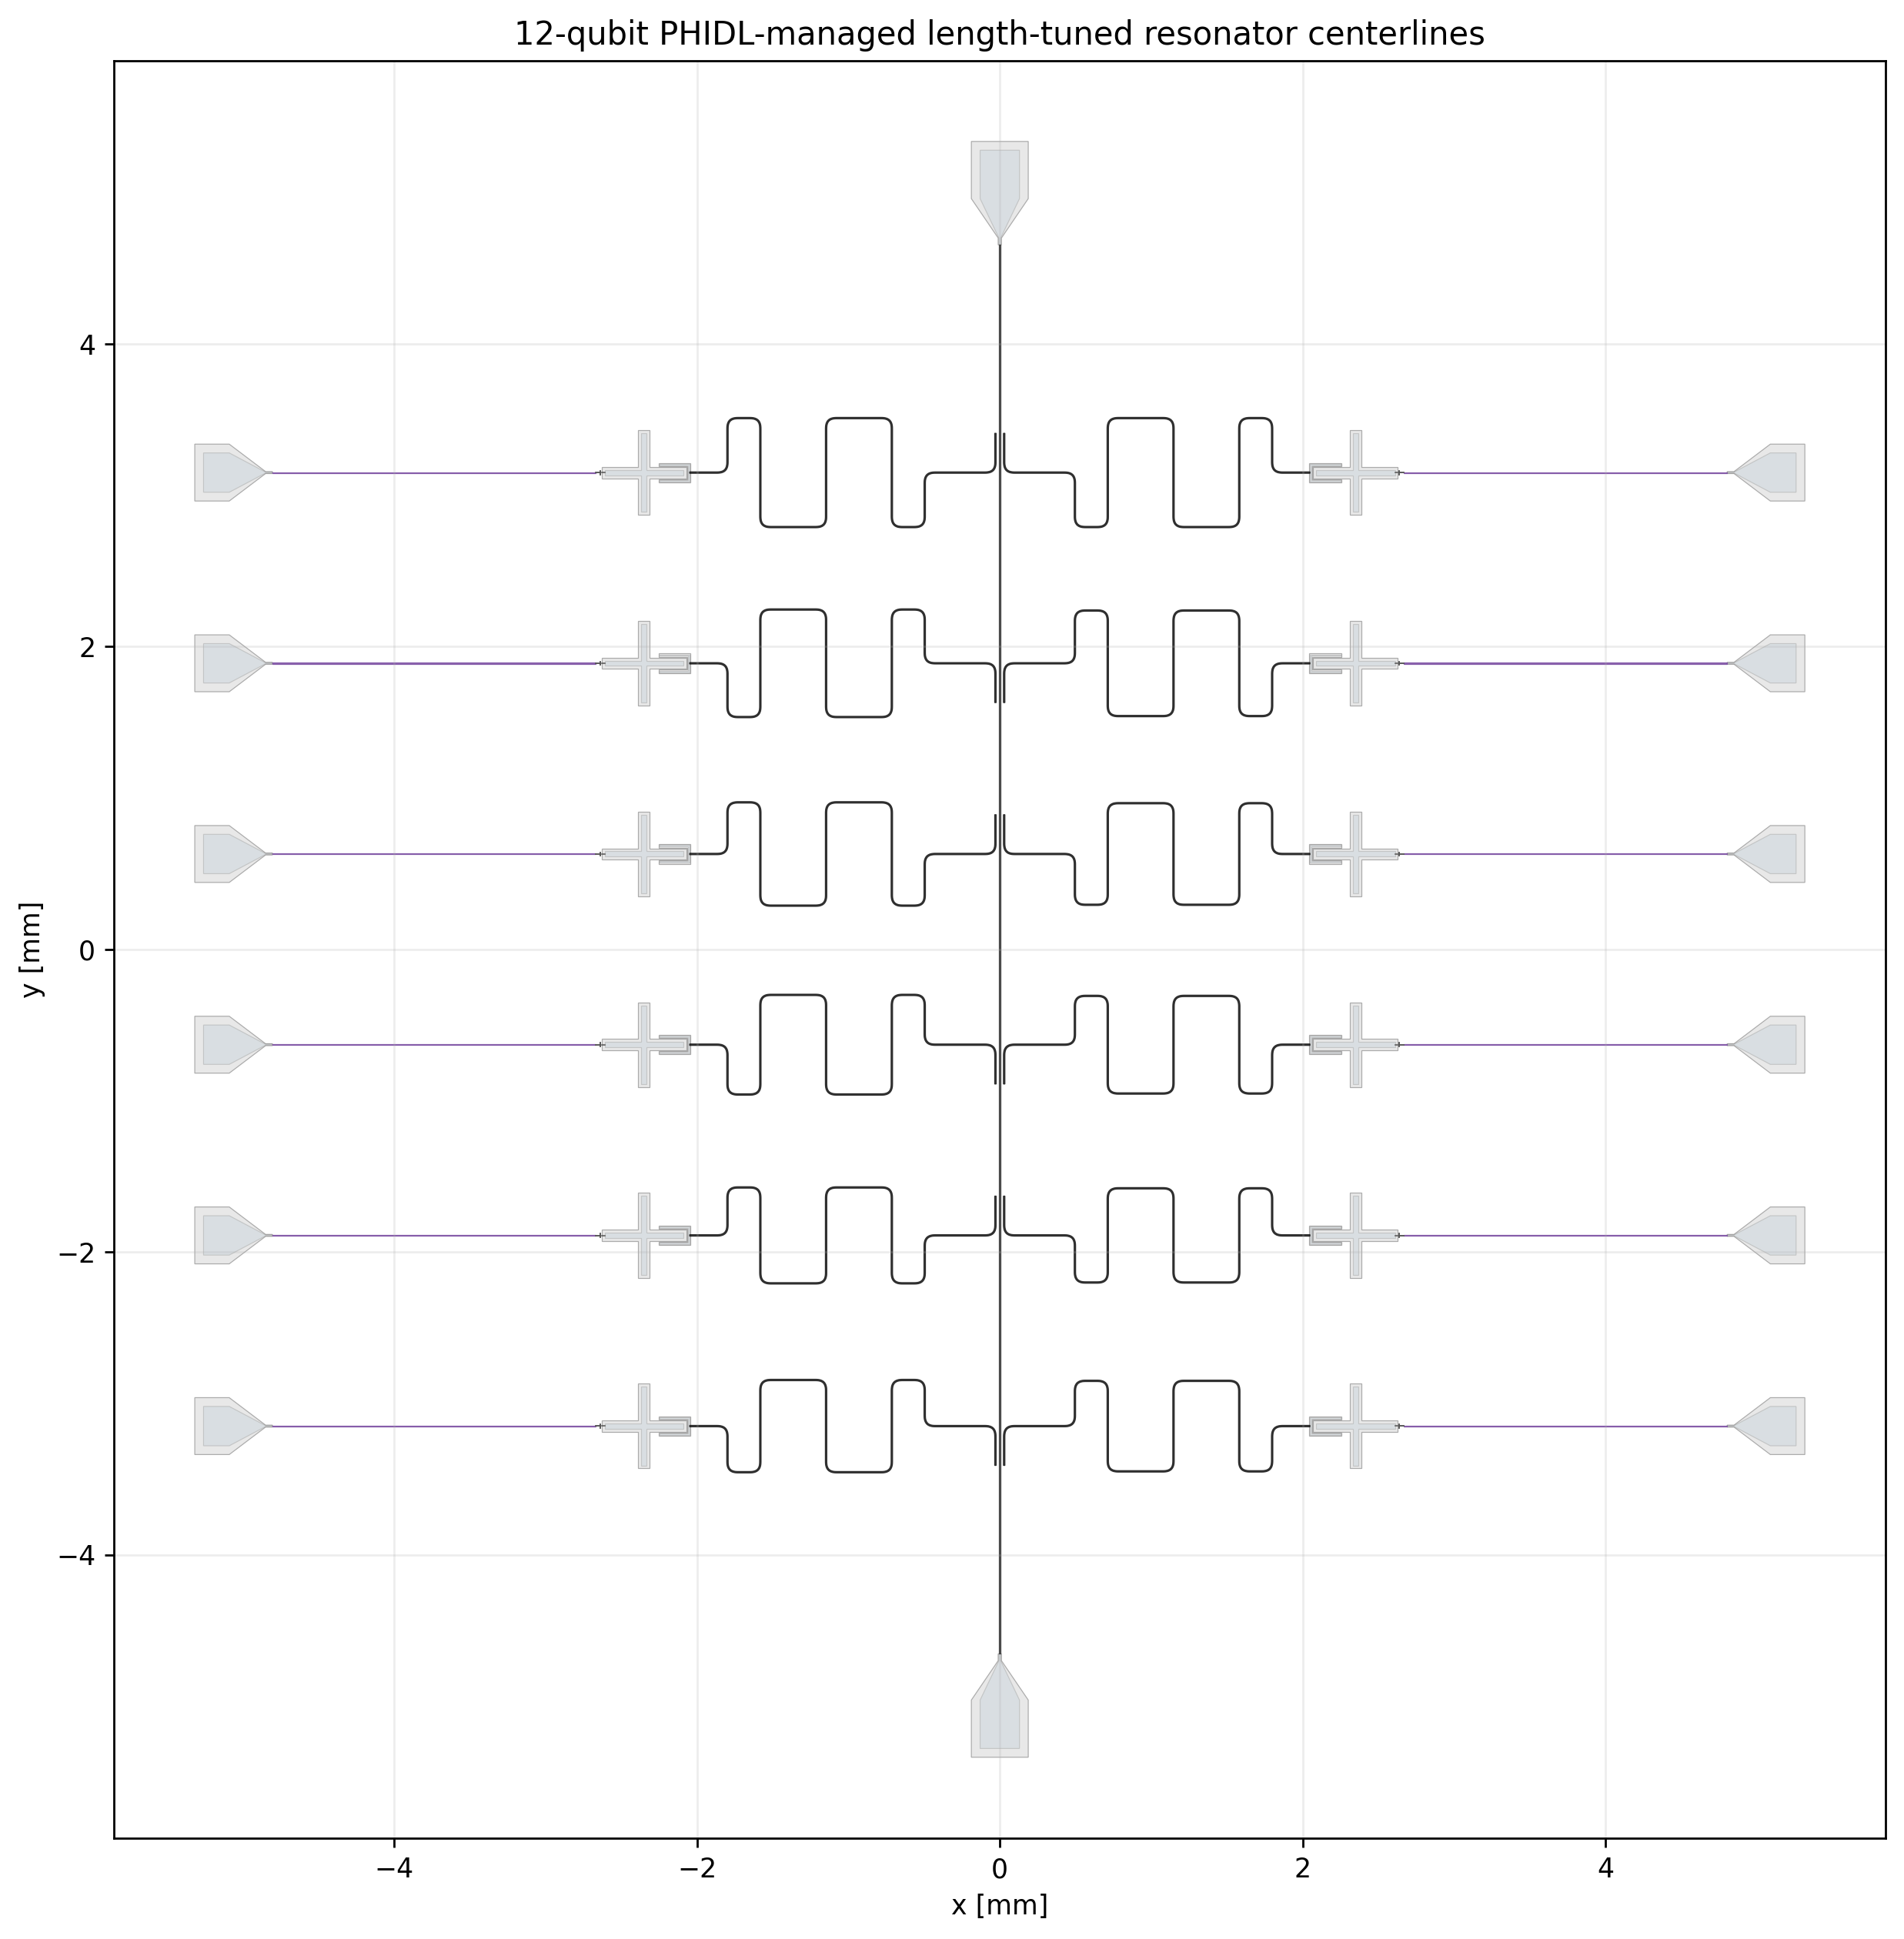


Wrote GDS: /content/twelve_qubit_flux_processor.gds

Export summary


,source,group,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,manual_cpw,feedline,3,12,1,1.089270e+05,5,5
1,manual_cpw,feedline,3,13,1,2.038890e+05,5,5
2,manual_cpw,flux_bias,5,0,12,1.531860e+05,7,7
3,manual_cpw,flux_bias,5,1,24,1.788120e+05,7,7
4,manual_cpw,readout_resonator,3,10,12,5.594579e+05,11390,11390
5,manual_cpw,readout_resonator,3,11,12,1.230807e+06,11390,11390
6,qgeometry,junction,9,0,12,8.400000e+03,5,5
7,qgeometry,path,3,0,24,3.240000e+03,5,5
8,qgeometry,path,3,1,24,7.128000e+03,5,5
9,qgeometry,poly,3,0,26,7.198350e+05,9,13



Manual CPW route audit


,route,group,points,length_um,target_length_um,length_error_um,target_frequency_ghz,effective_frequency_ghz,designed_amplitude_um,trace_width_um,gap_um,local_flux_trace_width_um,local_flux_gap_um,flux_taper_length_um,flux_taper_total_width_reduction_um,forced_flux_taper_end_gap_um,forced_taper_end_envelope_um,total_clearance_width_um,gap_slots_trimmed,exports_ground_cutout,requested_fillet_um,used_trace_fillet_um,used_clearance_fillet_um,phidl_centerline_management,managed_centerline_radius_um,polygon_count
0,readout_feedline,feedline,2,9310.000,nan,nan,nan,nan,nan,11.700,5.100,nan,nan,nan,nan,nan,nan,21.900,False,False,70.000,0.000,0.000,False,0.000,2
1,rr_Q01_L,readout_resonator,18,4885.900,4958.678,-72.777,6.050000,6.140117,360.000,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
2,rr_Q01_R,readout_resonator,18,4885.900,4901.961,-16.060,6.120000,6.140117,360.000,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
3,rr_Q02_L,readout_resonator,18,4848.396,4846.527,1.870,6.190000,6.187613,355.312,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
4,rr_Q02_R,readout_resonator,18,4795.900,4792.332,3.568,6.260000,6.255343,348.750,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
5,rr_Q03_L,readout_resonator,18,4735.900,4739.336,-3.436,6.330000,6.334593,341.250,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
6,rr_Q03_R,readout_resonator,18,4690.900,4687.500,3.400,6.400000,6.395361,335.625,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
7,rr_Q04_L,readout_resonator,18,4638.396,4636.785,1.611,6.470000,6.467753,329.062,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
8,rr_Q04_R,readout_resonator,18,4585.900,4587.156,-1.256,6.540000,6.541791,322.500,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2
9,rr_Q05_L,readout_resonator,18,4540.900,4538.578,2.322,6.610000,6.606619,316.875,10.000,6.000,nan,nan,nan,nan,nan,nan,22.000,False,False,85.000,41.650,41.650,True,41.650,2



Manual pad audit


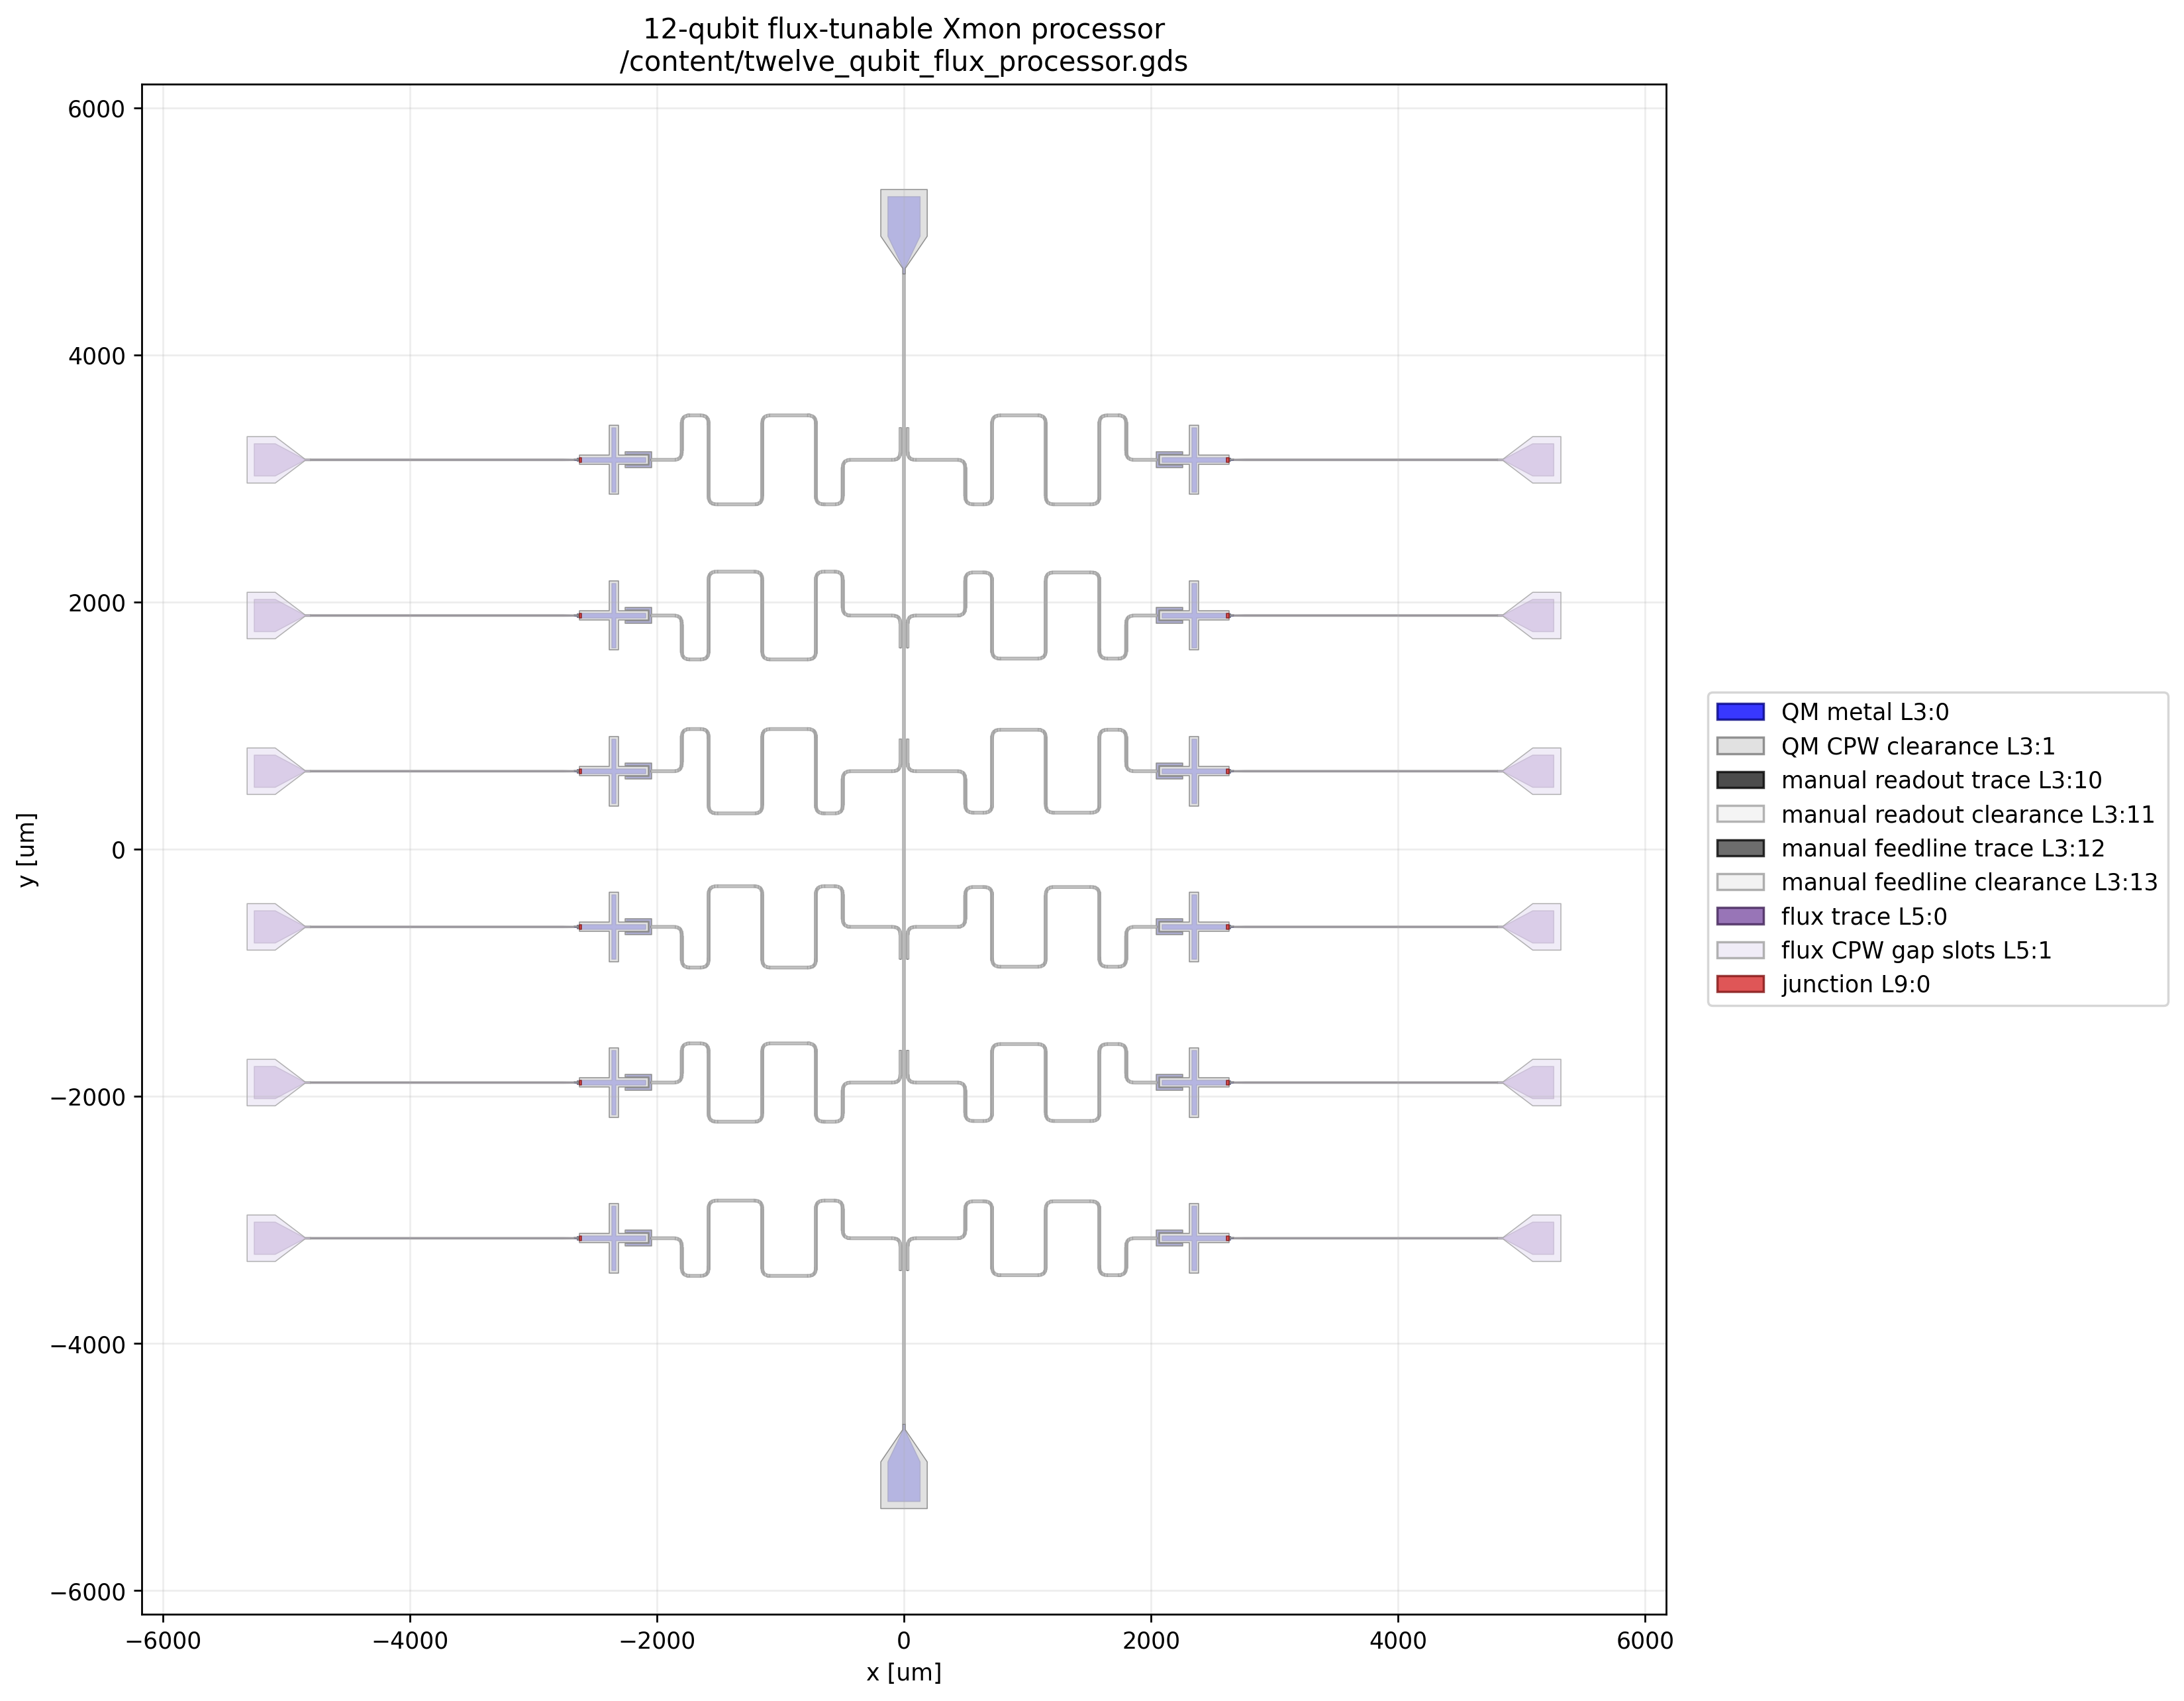

In [ ]:
"""
Build a 12-qubit flux-tunable Xmon processor with PHIDL-managed readout
resonator centerlines and frequency-multiplexed physical resonator lengths.

Quantum Metal creates the flux-line transmon cells and all wirebond launchpad
geometries. PHIDL owns centerline smoothing for the feedline and readout
resonator paths. GDSTK writes the final GDS, and Shapely is retained for
layer/datatype-aware CPW trace and side-slot polygon construction.

The readout resonators are individually length-targeted from the input
multiplexing frequencies using a quarter-wave first-pass model. The meander
amplitude for each resonator is solved so that the PHIDL-smoothed centerline length
tracks its own target physical length. This helps keep the twelve readout signals
separated on the shared microwave feedline.

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon

try:
    import phidl.path as pp
except Exception:  # noqa: BLE001
    pp = None

from qiskit_metal import Dict, config, designs
from qiskit_metal.qlibrary.qubits.transmon_cross_fl import TransmonCrossFL
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/twelve_qubit_flux_processor.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_PREVIEW: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_ROUTE_AUDITS: Final[bool] = True

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 13.0
FIGURE_HEIGHT_IN: Final[float] = 12.0

CHIP_SIZE_X: Final[str] = "11mm"
CHIP_SIZE_Y: Final[str] = "11mm"

COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

QM_METAL_LAYER: Final[int] = 3
QM_CLEARANCE_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0
JUNCTION_LAYER: Final[int] = 9

READOUT_TRACE_LAYER: Final[int] = 3
READOUT_CLEARANCE_LAYER: Final[int] = 3
FEEDLINE_TRACE_LAYER: Final[int] = 3
FEEDLINE_CLEARANCE_LAYER: Final[int] = 3
FLUX_TRACE_LAYER: Final[int] = 5
FLUX_CLEARANCE_LAYER: Final[int] = 5
FLUX_GROUND_CUTOUT_LAYER: Final[int] = 3
FLUX_GROUND_CUTOUT_DATATYPE: Final[int] = 14
EXPORT_FLUX_GROUND_CUTOUTS: Final[bool] = False

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.050,
    6.120,
    6.190,
    6.260,
    6.330,
    6.400,
    6.470,
    6.540,
    6.610,
    6.680,
    6.750,
    6.820,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8

FEEDLINE_TRACE_WIDTH_UM: Final[float] = 11.7
FEEDLINE_GAP_UM: Final[float] = 5.1
FEEDLINE_FILLET_UM: Final[float] = 70.0

READOUT_TRACE_WIDTH_UM: Final[float] = 10.0
READOUT_GAP_UM: Final[float] = 6.0
READOUT_FILLET_UM: Final[float] = 85.0
READOUT_MEANDER_AMPLITUDE_UM: Final[float] = 300.0
READOUT_LEAD_UM: Final[float] = 250.0
READOUT_TEETH: Final[int] = 3
READOUT_COUPLING_FINGER_LENGTH_UM: Final[float] = 260.0
READOUT_FEEDLINE_COUPLING_GAP_UM: Final[float] = 18.0

LENGTH_TUNE_RESONATORS: Final[bool] = True
RESONATOR_LENGTH_TARGET_SCALE: Final[float] = 1.0
RESONATOR_LENGTH_OFFSET_UM: Final[float] = 0.0
RESONATOR_LENGTH_FIT_TOLERANCE_UM: Final[float] = 5.0
RESONATOR_MIN_MEANDER_AMPLITUDE_UM: Final[float] = 120.0
RESONATOR_MAX_MEANDER_AMPLITUDE_UM: Final[float] = 360.0
RESONATOR_LENGTH_SOLVER_ITERATIONS: Final[int] = 28
RESONATOR_AMPLITUDE_DECIMALS: Final[int] = 3

FLUX_TRACE_WIDTH_UM: Final[float] = 6.0
FLUX_BASELINE_GAP_UM: Final[float] = 8.0
FLUX_TAPER_TOTAL_WIDTH_REDUCTION_UM: Final[float] = 9.0
FLUX_GAP_UM: Final[float] = (
    FLUX_BASELINE_GAP_UM - 0.5 * FLUX_TAPER_TOTAL_WIDTH_REDUCTION_UM
)
FORCE_FLUX_TAPER_END_GAP: Final[bool] = True
FORCED_FLUX_TAPER_END_GAP_UM: Final[float] = 3.5
FLUX_LOCAL_TRACE_WIDTH_UM: Final[float] = 5.0
FLUX_LOCAL_GAP_UM: Final[float] = 3.0
FLUX_TAPER_LENGTH_UM: Final[float] = 95.0
FLUX_TAPER_END_LENGTH_UM: Final[float] = 0.0
FLUX_FILLET_UM: Final[float] = 55.0
USE_QM_FLUX_PIN_FOR_ROUTE_START: Final[bool] = True
EXPORT_MANUAL_FLUX_GAPS: Final[bool] = True
TRIM_FLUX_GAPS_AWAY_FROM_ENDPOINTS: Final[bool] = False
FLUX_GAP_START_TRIM_UM: Final[float] = 0.0
FLUX_GAP_END_TRIM_UM: Final[float] = 0.0
FLUX_LOCAL_VERTICAL_UM: Final[float] = 0.0
FLUX_ESCAPE_UM: Final[float] = 360.0
FLUX_PAD_EDGE_X_UM: Final[float] = 4850.0
FLUX_PAD_WIDTH_UM: Final[float] = 260.0
FLUX_PAD_HEIGHT_UM: Final[float] = 150.0
FLUX_PAD_BODY_LENGTH_UM: Final[float] = 280.0
FLUX_PAD_TAPER_UM: Final[float] = 220.0
FLUX_PAD_NECK_UM: Final[float] = 42.0
FLUX_PAD_CLEARANCE_UM: Final[float] = 42.0

LAUNCH_PAD_WIDTH_UM: Final[float] = 260.0
LAUNCH_PAD_HEIGHT_UM: Final[float] = 320.0
LAUNCH_PAD_TAPER_UM: Final[float] = 260.0
LAUNCH_PAD_NECK_UM: Final[float] = 38.0
LAUNCH_PAD_CLEARANCE_UM: Final[float] = 60.0
LAUNCH_PAD_Y_UM: Final[float] = 4700.0
FEEDLINE_TOP_Y_UM: Final[float] = 4200.0
FEEDLINE_BOTTOM_Y_UM: Final[float] = -4200.0

DEFAULT_CROSS_LENGTH: Final[str] = "260um"
DEFAULT_CROSS_WIDTH: Final[str] = "35um"
DEFAULT_CROSS_GAP: Final[str] = "20um"
DEFAULT_CLAW_LENGTH: Final[str] = "190um"
DEFAULT_CLAW_WIDTH: Final[str] = "10um"
DEFAULT_CLAW_GAP: Final[str] = "6um"
DEFAULT_CLAW_CPW_LENGTH: Final[str] = "0um"
DEFAULT_GROUND_SPACING: Final[str] = "5um"
DEFAULT_LJ_NH: Final[float] = 15.903982052718824

LEFT_COLUMN_X_UM: Final[float] = -2350.0
RIGHT_COLUMN_X_UM: Final[float] = 2350.0
ROW_Y_UM: Final[tuple[float, ...]] = (
    3150.0,
    1890.0,
    630.0,
    -630.0,
    -1890.0,
    -3150.0,
)

MIN_FILLET_RADIUS_UM: Final[float] = 10.0
FILLET_SAFETY_FRACTION: Final[float] = 0.40
SAMPLES_PER_FILLET: Final[int] = 24
BUFFER_RESOLUTION: Final[int] = 32

USE_PHIDL_CENTERLINE_MANAGEMENT: Final[bool] = True
PHIDL_CORNER_STYLE: Final[str] = "euler"
PHIDL_EULER_USE_EFFECTIVE_RADIUS: Final[bool] = False
PHIDL_SMOOTH_RADIUS_SHRINK: Final[float] = 0.70
PHIDL_SMOOTH_MAX_RETRIES: Final[int] = 7
PHIDL_MIN_RADIUS_UM: Final[float] = 3.0
PHIDL_POINT_DECIMALS: Final[int] = 6

LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (QM_METAL_LAYER, NORMAL_DATATYPE): {
        "facecolor": "#0000FF",
        "edgecolor": "#000080",
        "label": "QM metal",
    },
    (QM_METAL_LAYER, QM_CLEARANCE_DATATYPE): {
        "facecolor": "#D9D9D9",
        "edgecolor": "#777777",
        "label": "QM CPW clearance",
    },
    (READOUT_TRACE_LAYER, 10): {
        "facecolor": "#1A1A1A",
        "edgecolor": "#000000",
        "label": "manual readout trace",
    },
    (READOUT_CLEARANCE_LAYER, 11): {
        "facecolor": "#F2F2F2",
        "edgecolor": "#A0A0A0",
        "label": "manual readout clearance",
    },
    (FEEDLINE_TRACE_LAYER, 12): {
        "facecolor": "#444444",
        "edgecolor": "#000000",
        "label": "manual feedline trace",
    },
    (FEEDLINE_CLEARANCE_LAYER, 13): {
        "facecolor": "#EFEFEF",
        "edgecolor": "#9A9A9A",
        "label": "manual feedline clearance",
    },
    (FLUX_TRACE_LAYER, NORMAL_DATATYPE): {
        "facecolor": "#7B4EA3",
        "edgecolor": "#3E2055",
        "label": "flux trace",
    },
    (FLUX_CLEARANCE_LAYER, QM_CLEARANCE_DATATYPE): {
        "facecolor": "#EDE7F6",
        "edgecolor": "#9E9E9E",
        "label": "flux CPW gap slots",
    },
    (FLUX_GROUND_CUTOUT_LAYER, FLUX_GROUND_CUTOUT_DATATYPE): {
        "facecolor": "#FFF2CC",
        "edgecolor": "#A08000",
        "label": "flux ground cutout",
    },
    (JUNCTION_LAYER, NORMAL_DATATYPE): {
        "facecolor": "#D62728",
        "edgecolor": "#7F1010",
        "label": "junction",
    },
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "other",
}

mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    if not hasattr(config, "renderers_to_load"):
        config.renderers_to_load = Dict()
except Exception:
    pass


# =============================================================================
# DATA STRUCTURES
# =============================================================================


@dataclass(frozen=True)
class QubitSite:
    """Processor placement metadata for one flux-tunable Xmon."""

    name: str
    row: int
    side: str
    x_um: float
    y_um: float
    orientation: str


@dataclass(frozen=True)
class ManualCpw:
    """Manual CPW route exported as trace and clearance polygons."""

    name: str
    group: str
    centerline_um: tuple[tuple[float, float], ...]
    trace_width_um: float
    gap_um: float
    fillet_um: float
    trace_layer: int
    trace_datatype: int
    clearance_layer: int
    clearance_datatype: int
    target_length_um: float | None = None
    target_frequency_ghz: float | None = None
    designed_amplitude_um: float | None = None


@dataclass(frozen=True)
class ManualPad:
    """Manual polygonal pad with clearance."""

    name: str
    group: str
    polygon_um: tuple[tuple[float, float], ...]
    clearance_um: float
    trace_layer: int
    trace_datatype: int
    clearance_layer: int
    clearance_datatype: int


@dataclass(frozen=True)
class BuildResult:
    """Container for the completed design and manual layout primitives."""

    design: Any
    qubits: list[Any]
    launchpads: list[Any]
    sites: tuple[QubitSite, ...]
    cpws: tuple[ManualCpw, ...]
    pads: tuple[ManualPad, ...]
    route_table: pd.DataFrame


# =============================================================================
# PLACEMENT AND PARAMETER HELPERS
# =============================================================================


def build_qubit_sites() -> tuple[QubitSite, ...]:
    """Create a two-column 12-qubit placement plan."""
    sites: list[QubitSite] = []

    for row_index, y_um in enumerate(ROW_Y_UM):
        sites.append(
            QubitSite(
                name=f"Q{row_index + 1:02d}_L",
                row=row_index,
                side="left",
                x_um=LEFT_COLUMN_X_UM,
                y_um=y_um,
                orientation="-90",
            )
        )
        sites.append(
            QubitSite(
                name=f"Q{row_index + 1:02d}_R",
                row=row_index,
                side="right",
                x_um=RIGHT_COLUMN_X_UM,
                y_um=y_um,
                orientation="90",
            )
        )

    return tuple(sites)


QUBIT_SITES: Final[tuple[QubitSite, ...]] = build_qubit_sites()


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave readout lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)
    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def um_to_qm(value_um: float) -> str:
    """Format a micrometer coordinate for Quantum Metal."""
    return f"{value_um:.6f}um"


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = QM_METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def clean_coords(coords: Any) -> np.ndarray:
    """Return finite, duplicate-free 2D coordinates."""
    array = np.asarray(coords, dtype=float)

    if array.ndim != 2 or array.shape[1] < 2:
        return np.empty((0, 2), dtype=float)

    array = array[:, :2]
    array = array[np.isfinite(array).all(axis=1)]

    if array.shape[0] == 0:
        return array

    cleaned = [array[0]]
    for point in array[1:]:
        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated points from a centerline."""
    if points.shape[0] <= 1:
        return points

    output = [points[0]]
    for point in points[1:]:
        if np.linalg.norm(point - output[-1]) > 1.0e-9:
            output.append(point)

    return np.asarray(output, dtype=float)



def phidl_is_available() -> bool:
    """Return whether PHIDL path management is available in this runtime."""
    return pp is not None


def phidl_corner_function() -> Any:
    """Return the requested PHIDL corner smoothing function."""
    if pp is None:
        return None

    corner_style = PHIDL_CORNER_STYLE.strip().lower()
    if corner_style == "arc":
        return pp.arc
    return pp.euler


def raw_polyline_length_um(points: np.ndarray) -> float:
    """Return the arc length of a polyline in micrometers."""
    if points.shape[0] < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(points, axis=0), axis=1)))


def phidl_managed_centerline_points_um(
    points_um: np.ndarray,
    requested_radius_um: float,
) -> tuple[np.ndarray, float, bool]:
    """Smooth and sample a centerline using PHIDL when possible.

    PHIDL is used here as the path manager. The design still converts the
    resulting path into Shapely polygons because the CPW export needs explicit
    trace polygons and physical side-slot gap polygons on separate GDS
    datatypes. This function keeps PHIDL responsible for interpreting the
    waypoint list and selecting the rounded corner path.
    """
    points = clean_line_points(points_um)

    if (
        not USE_PHIDL_CENTERLINE_MANAGEMENT
        or not phidl_is_available()
        or points.shape[0] < 3
    ):
        rounded_points, used_radius = manual_rounded_centerline_points_um(
            points,
            requested_radius_um,
        )
        return rounded_points, used_radius, False

    safe_radius = safe_corner_radius_um(points, requested_radius_um)
    if safe_radius <= 0.0:
        return points, 0.0, False

    corner_fun = phidl_corner_function()
    radius_um = max(min(float(safe_radius), float(requested_radius_um)), 0.0)
    last_error: Exception | None = None

    for _ in range(PHIDL_SMOOTH_MAX_RETRIES):
        if radius_um < PHIDL_MIN_RADIUS_UM:
            break

        try:
            if PHIDL_CORNER_STYLE.strip().lower() == "euler":
                path = pp.smooth(
                    points=points,
                    radius=radius_um,
                    corner_fun=corner_fun,
                    use_eff=PHIDL_EULER_USE_EFFECTIVE_RADIUS,
                )
            else:
                path = pp.smooth(
                    points=points,
                    radius=radius_um,
                    corner_fun=corner_fun,
                )
            path_points = clean_line_points(np.asarray(path.points, dtype=float))
            if path_points.shape[0] >= 2 and raw_polyline_length_um(path_points) > 0.0:
                path_points = np.round(path_points, decimals=PHIDL_POINT_DECIMALS)
                return path_points, radius_um, True
        except TypeError as error:
            last_error = error
            try:
                path = pp.smooth(
                    points=points,
                    radius=radius_um,
                    corner_fun=corner_fun,
                )
                path_points = clean_line_points(np.asarray(path.points, dtype=float))
                if path_points.shape[0] >= 2 and raw_polyline_length_um(path_points) > 0.0:
                    path_points = np.round(path_points, decimals=PHIDL_POINT_DECIMALS)
                    return path_points, radius_um, True
            except Exception as nested_error:  # noqa: BLE001
                last_error = nested_error
        except Exception as error:  # noqa: BLE001
            last_error = error

        radius_um *= PHIDL_SMOOTH_RADIUS_SHRINK

    if last_error is not None:
        print(
            "PHIDL centerline fallback: "
            f"{type(last_error).__name__}: {last_error}"
        )

    rounded_points, used_radius = manual_rounded_centerline_points_um(
        points,
        requested_radius_um,
    )
    return rounded_points, used_radius, False


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier curve used for a rounded route corner."""
    t_values = np.linspace(0.0, 1.0, samples)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control
        + (t_values**2)[:, None] * end
    )


def safe_corner_radius_um(points: np.ndarray, requested_radius_um: float) -> float:
    """Clamp a fillet radius to the shortest adjacent route segment."""
    if points.shape[0] < 3:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    positive_lengths = segment_lengths[segment_lengths > 1.0e-9]

    if positive_lengths.size == 0:
        return 0.0

    safe_radius = FILLET_SAFETY_FRACTION * float(np.min(positive_lengths))
    radius = min(float(requested_radius_um), safe_radius)

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def manual_rounded_centerline_points_um(
    points_um: np.ndarray,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a sampled rounded centerline and the radius used."""
    points = clean_line_points(points_um)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length
        cosine_angle = float(np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0))
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            if np.linalg.norm(output[-1] - corner_point) > 1.0e-9:
                output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(trim_um, 0.45 * incoming_length, 0.45 * outgoing_length)

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um



def rounded_centerline_points_um(
    points_um: np.ndarray,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a PHIDL-managed rounded centerline and the radius used."""
    rounded_points, used_radius, _ = phidl_managed_centerline_points_um(
        points_um=points_um,
        requested_radius_um=requested_radius_um,
    )
    return rounded_points, used_radius


def managed_centerline_length_um(
    centerline_um: tuple[tuple[float, float], ...],
    requested_radius_um: float,
) -> tuple[float, float, bool]:
    """Return PHIDL-managed centerline length, used radius, and PHIDL flag."""
    points = np.asarray(centerline_um, dtype=float)
    managed_points, used_radius_um, phidl_used = phidl_managed_centerline_points_um(
        points_um=points,
        requested_radius_um=requested_radius_um,
    )
    return raw_polyline_length_um(managed_points), used_radius_um, phidl_used


def centerline_to_polygon_um(
    centerline_um: tuple[tuple[float, float], ...],
    width_um: float,
    requested_radius_um: float,
) -> tuple[Any, float]:
    """Convert a centerline into a rounded Shapely trace polygon."""
    points = np.asarray(centerline_um, dtype=float)
    rounded_points, used_radius_um = rounded_centerline_points_um(
        points_um=points,
        requested_radius_um=requested_radius_um,
    )

    if rounded_points.shape[0] < 2:
        return Polygon(), used_radius_um

    geometry = LineString(rounded_points).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return geometry, used_radius_um


def centerline_to_cpw_slot_pair_um(
    centerline_um: tuple[tuple[float, float], ...],
    trace_width_um: float,
    gap_um: float,
    requested_radius_um: float,
) -> tuple[Any, float]:
    """Return only the two CPW gap slots around a rounded center trace.

    A filled clearance polygon is useful for quick visual checks, but it can
    look incoherent in a mask viewer because it covers the center trace.  A
    physical coplanar waveguide gap is the annular difference between the
    outer trace-plus-gap envelope and the center trace itself.  Exporting this
    difference produces two side slots, with the center conductor left open on
    the flux metal layer.
    """
    if gap_um <= 0.0:
        return Polygon(), 0.0

    outer_geometry, used_radius_um = centerline_to_polygon_um(
        centerline_um=centerline_um,
        width_um=trace_width_um + 2.0 * gap_um,
        requested_radius_um=requested_radius_um,
    )
    trace_geometry, _ = centerline_to_polygon_um(
        centerline_um=centerline_um,
        width_um=trace_width_um,
        requested_radius_um=requested_radius_um,
    )

    if outer_geometry.is_empty or trace_geometry.is_empty:
        return Polygon(), used_radius_um

    return outer_geometry.difference(trace_geometry), used_radius_um



def tapered_horizontal_flux_geometries(
    cpw: ManualCpw,
) -> tuple[Any, Any, float, float]:
    """Create a horizontal flux CPW with a local tapered T transition.

    The local TransmonCrossFL flux feature uses a narrower T than the long-run
    fanout CPW.  A constant-width manual CPW therefore makes the T look skinny
    beside a broad gap region.  For flux-bias routes that are effectively
    horizontal, this helper generates a trace polygon whose width changes from
    ``FLUX_LOCAL_TRACE_WIDTH_UM`` to ``FLUX_TRACE_WIDTH_UM`` over
    ``FLUX_TAPER_LENGTH_UM``.  The CPW slots are generated as two side polygons
    whose slot spacing changes from ``FLUX_LOCAL_GAP_UM`` to ``FLUX_GAP_UM``
    over the same transition.  The center metal stays continuous from the local
    T connection to the Quantum Metal launchpad tie pin.
    """
    points = clean_line_points(np.asarray(cpw.centerline_um, dtype=float))

    if points.shape[0] < 2:
        return Polygon(), Polygon(), 0.0, 0.0

    y_values = points[:, 1]
    if float(np.max(np.abs(y_values - y_values[0]))) > 1.0e-6:
        trace_geometry, used_trace_radius = centerline_to_polygon_um(
            centerline_um=cpw.centerline_um,
            width_um=cpw.trace_width_um,
            requested_radius_um=cpw.fillet_um,
        )
        clearance_geometry, used_clearance_radius = centerline_to_cpw_slot_pair_um(
            centerline_um=cpw.centerline_um,
            trace_width_um=cpw.trace_width_um,
            gap_um=cpw.gap_um,
            requested_radius_um=cpw.fillet_um,
        )
        return trace_geometry, clearance_geometry, used_trace_radius, used_clearance_radius

    x0 = float(points[0, 0])
    x1 = float(points[-1, 0])
    y0 = float(points[0, 1])
    span_um = abs(x1 - x0)

    if span_um <= max(4.0 * FLUX_TAPER_LENGTH_UM, 1.0):
        trace_geometry, used_trace_radius = centerline_to_polygon_um(
            centerline_um=cpw.centerline_um,
            width_um=cpw.trace_width_um,
            requested_radius_um=cpw.fillet_um,
        )
        clearance_geometry, used_clearance_radius = centerline_to_cpw_slot_pair_um(
            centerline_um=cpw.centerline_um,
            trace_width_um=cpw.trace_width_um,
            gap_um=cpw.gap_um,
            requested_radius_um=cpw.fillet_um,
        )
        return trace_geometry, clearance_geometry, used_trace_radius, used_clearance_radius

    direction = 1.0 if x1 >= x0 else -1.0
    taper_um = min(FLUX_TAPER_LENGTH_UM, 0.25 * span_um)
    xt = x0 + direction * taper_um

    local_half_trace = 0.5 * FLUX_LOCAL_TRACE_WIDTH_UM
    main_half_trace = 0.5 * cpw.trace_width_um
    main_gap_um = cpw.gap_um
    if FORCE_FLUX_TAPER_END_GAP:
        main_gap_um = min(main_gap_um, FORCED_FLUX_TAPER_END_GAP_UM)
    local_half_envelope = local_half_trace + FLUX_LOCAL_GAP_UM
    main_half_envelope = main_half_trace + main_gap_um

    trace_polygon = Polygon(
        [
            (x0, y0 - local_half_trace),
            (xt, y0 - main_half_trace),
            (x1, y0 - main_half_trace),
            (x1, y0 + main_half_trace),
            (xt, y0 + main_half_trace),
            (x0, y0 + local_half_trace),
        ]
    ).buffer(0.0)

    top_slot = Polygon(
        [
            (x0, y0 + local_half_trace),
            (xt, y0 + main_half_trace),
            (x1, y0 + main_half_trace),
            (x1, y0 + main_half_envelope),
            (xt, y0 + main_half_envelope),
            (x0, y0 + local_half_envelope),
        ]
    ).buffer(0.0)
    bottom_slot = Polygon(
        [
            (x0, y0 - local_half_trace),
            (xt, y0 - main_half_trace),
            (x1, y0 - main_half_trace),
            (x1, y0 - main_half_envelope),
            (xt, y0 - main_half_envelope),
            (x0, y0 - local_half_envelope),
        ]
    ).buffer(0.0)

    clearance_geometry = MultiPolygon([top_slot, bottom_slot]).buffer(0.0)
    return trace_polygon, clearance_geometry, 0.0, 0.0

def trim_centerline_um(
    centerline_um: tuple[tuple[float, float], ...],
    start_trim_um: float,
    end_trim_um: float,
) -> tuple[tuple[float, float], ...]:
    """Trim a polyline by arc length while preserving intermediate corners.

    The flux trace itself must reach the TransmonCrossFL local T feature and
    the Quantum Metal launchpad tie pin.  The CPW gap slots, however, should
    stay away from those endpoint geometries because the qubit component and
    launcher already contain their own local gap or keepout features.  This
    helper returns the centerline segment over which manually generated flux
    CPW slots are allowed to exist.
    """
    points = clean_line_points(np.asarray(centerline_um, dtype=float))

    if points.shape[0] < 2:
        return tuple(map(tuple, points))

    segment_vectors = np.diff(points, axis=0)
    segment_lengths = np.linalg.norm(segment_vectors, axis=1)
    total_length = float(np.sum(segment_lengths))

    if total_length <= 1.0e-9:
        return tuple(map(tuple, points))

    start_s = max(float(start_trim_um), 0.0)
    end_s = max(total_length - max(float(end_trim_um), 0.0), start_s)

    if end_s - start_s < max(4.0 * FLUX_GAP_UM, 20.0):
        return tuple(map(tuple, points))

    cumulative = np.concatenate([[0.0], np.cumsum(segment_lengths)])

    def point_at(distance_um: float) -> np.ndarray:
        if distance_um <= 0.0:
            return points[0]
        if distance_um >= total_length:
            return points[-1]

        seg_index = int(np.searchsorted(cumulative, distance_um, side="right") - 1)
        seg_index = max(0, min(seg_index, len(segment_lengths) - 1))
        seg_len = segment_lengths[seg_index]
        if seg_len <= 1.0e-12:
            return points[seg_index]
        alpha = (distance_um - cumulative[seg_index]) / seg_len
        return points[seg_index] + alpha * segment_vectors[seg_index]

    trimmed: list[np.ndarray] = [point_at(start_s)]
    for index in range(1, len(points) - 1):
        if start_s < cumulative[index] < end_s:
            trimmed.append(points[index])
    trimmed.append(point_at(end_s))

    cleaned = clean_line_points(np.asarray(trimmed, dtype=float))
    return tuple((float(x), float(y)) for x, y in cleaned)


# =============================================================================
# QUANTUM METAL BUILD
# =============================================================================


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = f"{READOUT_TRACE_WIDTH_UM:.6f}um"
    design.variables["cpw_gap"] = f"{READOUT_GAP_UM:.6f}um"
    return design


def create_flux_xmon(design: Any, site: QubitSite) -> Any:
    """Create a Quantum Metal flux-line Xmon."""
    return TransmonCrossFL(
        design,
        site.name,
        options=Dict(
            pos_x=um_to_qm(site.x_um),
            pos_y=um_to_qm(site.y_um),
            orientation=site.orientation,
            layer=str(QM_METAL_LAYER),
            cross_width=DEFAULT_CROSS_WIDTH,
            cross_length=DEFAULT_CROSS_LENGTH,
            cross_gap=DEFAULT_CROSS_GAP,
            make_fl=True,
            fl_options=Dict(
                t_top="24um",
                t_offset="0um",
                t_inductive_gap="4um",
                t_width="5um",
                t_gap="3um",
            ),
            connection_pads=Dict(
                c=Dict(
                    connector_location="90",
                    connector_type="0",
                    claw_length=DEFAULT_CLAW_LENGTH,
                    claw_gap=DEFAULT_CLAW_GAP,
                    claw_width=DEFAULT_CLAW_WIDTH,
                    claw_cpw_length=DEFAULT_CLAW_CPW_LENGTH,
                    claw_cpw_width=f"{READOUT_TRACE_WIDTH_UM:.6f}um",
                    ground_spacing=DEFAULT_GROUND_SPACING,
                )
            ),
            hfss_inductance=f"{DEFAULT_LJ_NH}nH",
            aedt_hfss_inductance=f"{DEFAULT_LJ_NH}nH",
        ),
    )


def rebuild_design(design: Any) -> None:
    """Regenerate all Quantum Metal qgeometry tables."""
    try:
        design.rebuild()
    except Exception:
        for component in design.components.values():
            try:
                component.rebuild()
            except Exception:
                pass


def pin_middle_um(component: Any, preferred_names: tuple[str, ...]) -> tuple[float, float] | None:
    """Return the midpoint of a Quantum Metal pin in micrometers."""
    for pin_name in preferred_names:
        if pin_name not in component.pins:
            continue

        pin = component.pins[pin_name]
        for key in ("middle", "points"):
            if key not in pin:
                continue

            value = np.asarray(pin[key], dtype=float)
            if key == "points" and value.ndim == 2:
                value = np.mean(value[:, :2], axis=0)

            if value.size >= 2 and np.isfinite(value[:2]).all():
                return (
                    float(value[0]) * COORD_SCALE_TO_UM,
                    float(value[1]) * COORD_SCALE_TO_UM,
                )

    return None


def fallback_readout_pin(site: QubitSite) -> tuple[float, float]:
    """Return a safe approximate readout claw point."""
    toward_center = 1.0 if site.side == "left" else -1.0
    return (site.x_um + toward_center * 430.0, site.y_um)



def create_feedline_launchpads(design: Any) -> tuple[Any, Any]:
    """Create Quantum Metal wirebond launchpads for the readout feedline."""
    top = LaunchpadWirebond(
        design,
        "wb_readout_top",
        options=Dict(
            pos_x="0um",
            pos_y=um_to_qm(LAUNCH_PAD_Y_UM),
            orientation="-90",
            trace_width=f"{FEEDLINE_TRACE_WIDTH_UM:.6f}um",
            trace_gap=f"{FEEDLINE_GAP_UM:.6f}um",
            lead_length="45um",
            pad_width="260um",
            pad_height="320um",
            pad_gap="58um",
            taper_height="260um",
            layer=str(QM_METAL_LAYER),
        ),
    )
    bottom = LaunchpadWirebond(
        design,
        "wb_readout_bottom",
        options=Dict(
            pos_x="0um",
            pos_y=um_to_qm(-LAUNCH_PAD_Y_UM),
            orientation="90",
            trace_width=f"{FEEDLINE_TRACE_WIDTH_UM:.6f}um",
            trace_gap=f"{FEEDLINE_GAP_UM:.6f}um",
            lead_length="45um",
            pad_width="260um",
            pad_height="320um",
            pad_gap="58um",
            taper_height="260um",
            layer=str(QM_METAL_LAYER),
        ),
    )
    return top, bottom


def flux_launcher_name(site: QubitSite) -> str:
    """Return the Quantum Metal flux launchpad component name."""
    return f"wb_flux_{site.name}"


def resolve_flux_tap_um(site: QubitSite, qubit: Any) -> tuple[float, float]:
    """Return the flux-route start point in micrometers.

    The Quantum Metal TransmonCrossFL pin is used when it lies on the
    outer side of the Xmon. Otherwise the deterministic outer tap is used.
    This keeps the flux CPW attached to the local flux feature while avoiding
    routes through the readout claw region.
    """
    side_sign = -1.0 if site.side == "left" else 1.0
    expected_tap = (site.x_um + side_sign * 185.0, site.y_um - 120.0)

    if not USE_QM_FLUX_PIN_FOR_ROUTE_START:
        return expected_tap

    flux_pin = pin_middle_um(qubit, ("flux_line", "flux", "fl"))
    if flux_pin is None:
        return expected_tap

    pin_x = float(flux_pin[0])
    pin_y = float(flux_pin[1])
    is_outer_side = (side_sign < 0.0 and pin_x < site.x_um) or (
        side_sign > 0.0 and pin_x > site.x_um
    )

    if is_outer_side:
        return (pin_x, pin_y)

    return expected_tap


def create_flux_launchpads(
    design: Any,
    qubits_by_name: dict[str, Any],
) -> list[Any]:
    """Create Quantum Metal side launchpads aligned to each flux tap."""
    launchpads: list[Any] = []
    for site in QUBIT_SITES:
        side_sign = -1.0 if site.side == "left" else 1.0
        orientation = "0" if site.side == "left" else "180"
        _, lane_y = resolve_flux_tap_um(site, qubits_by_name[site.name])
        launchpads.append(
            LaunchpadWirebond(
                design,
                flux_launcher_name(site),
                options=Dict(
                    pos_x=um_to_qm(side_sign * FLUX_PAD_EDGE_X_UM),
                    pos_y=um_to_qm(lane_y),
                    orientation=orientation,
                    trace_width=f"{FLUX_TRACE_WIDTH_UM:.6f}um",
                    trace_gap=f"{FLUX_GAP_UM:.6f}um",
                    lead_length="45um",
                    pad_width="260um",
                    pad_height="170um",
                    pad_gap=f"{max(58.0, 2.0 * FLUX_GAP_UM + 24.0):.6f}um",
                    taper_height="240um",
                    layer=str(FLUX_TRACE_LAYER),
                ),
            )
        )
    return launchpads


def launchpad_tie_um(component: Any, fallback_um: tuple[float, float]) -> tuple[float, float]:
    """Return a robust tie-pin coordinate from a Quantum Metal launchpad."""
    for pin_name in ("tie", "in", "out", "a", "b"):
        point = pin_middle_um(component, (pin_name,))
        if point is not None:
            return (float(point[0]), float(point[1]))
    return fallback_um

def fallback_flux_pin(site: QubitSite) -> tuple[float, float]:
    """Return a safe approximate local flux-line start point."""
    away_from_center = -1.0 if site.side == "left" else 1.0
    return (site.x_um + away_from_center * 180.0, site.y_um - 120.0)


# =============================================================================
# MANUAL CPW ROUTING
# =============================================================================


def feedline_cpw(top_launch: Any, bottom_launch: Any) -> ManualCpw:
    """Return the central readout feedline CPW between Quantum Metal launchpads."""
    top_pin = launchpad_tie_um(top_launch, (0.0, FEEDLINE_TOP_Y_UM))
    bottom_pin = launchpad_tie_um(bottom_launch, (0.0, FEEDLINE_BOTTOM_Y_UM))
    return ManualCpw(
        name="readout_feedline",
        group="feedline",
        centerline_um=(bottom_pin, top_pin),
        trace_width_um=FEEDLINE_TRACE_WIDTH_UM,
        gap_um=FEEDLINE_GAP_UM,
        fillet_um=FEEDLINE_FILLET_UM,
        trace_layer=FEEDLINE_TRACE_LAYER,
        trace_datatype=12,
        clearance_layer=FEEDLINE_CLEARANCE_LAYER,
        clearance_datatype=13,
    )


def launch_pad_polygon(top: bool) -> tuple[tuple[float, float], ...]:
    """Return a valid tapered CPW launch pad polygon.

    The previous launcher used a concave vertex order that could render as an
    oversized block in KLayout when its clearance buffer was shown. This version
    uses a monotonic taper plus a rectangular neck that overlaps the feedline
    trace. The polygon stays simple, fabrication-style, and visually coherent.
    """
    sign = 1.0 if top else -1.0
    half_w = 0.5 * LAUNCH_PAD_WIDTH_UM
    neck_half = 0.5 * LAUNCH_PAD_NECK_UM

    neck_y = FEEDLINE_TOP_Y_UM if top else FEEDLINE_BOTTOM_Y_UM
    taper_start_y = sign * (LAUNCH_PAD_Y_UM - LAUNCH_PAD_HEIGHT_UM)
    body_inner_y = sign * (LAUNCH_PAD_Y_UM - LAUNCH_PAD_TAPER_UM)
    body_outer_y = sign * LAUNCH_PAD_Y_UM

    if top:
        return (
            (-neck_half, neck_y),
            (neck_half, neck_y),
            (neck_half, taper_start_y),
            (half_w, body_inner_y),
            (half_w, body_outer_y),
            (-half_w, body_outer_y),
            (-half_w, body_inner_y),
            (-neck_half, taper_start_y),
        )

    return (
        (-neck_half, neck_y),
        (neck_half, neck_y),
        (neck_half, taper_start_y),
        (half_w, body_inner_y),
        (half_w, body_outer_y),
        (-half_w, body_outer_y),
        (-half_w, body_inner_y),
        (-neck_half, taper_start_y),
    )

def launch_pads() -> tuple[ManualPad, ManualPad]:
    """Return top and bottom feedline launch pads."""
    return (
        ManualPad(
            name="launch_top",
            group="feedline_launch",
            polygon_um=launch_pad_polygon(top=True),
            clearance_um=LAUNCH_PAD_CLEARANCE_UM,
            trace_layer=FEEDLINE_TRACE_LAYER,
            trace_datatype=12,
            clearance_layer=FEEDLINE_CLEARANCE_LAYER,
            clearance_datatype=13,
        ),
        ManualPad(
            name="launch_bottom",
            group="feedline_launch",
            polygon_um=launch_pad_polygon(top=False),
            clearance_um=LAUNCH_PAD_CLEARANCE_UM,
            trace_layer=FEEDLINE_TRACE_LAYER,
            trace_datatype=12,
            clearance_layer=FEEDLINE_CLEARANCE_LAYER,
            clearance_datatype=13,
        ),
    )


def readout_coupler_x_um(site: QubitSite) -> float:
    """Return the resonator coupling finger x-position near the feedline."""
    sign = -1.0 if site.side == "left" else 1.0
    return sign * (
        0.5 * FEEDLINE_TRACE_WIDTH_UM
        + READOUT_FEEDLINE_COUPLING_GAP_UM
        + 0.5 * READOUT_TRACE_WIDTH_UM
    )


def build_meander_with_amplitude(
    start_um: tuple[float, float],
    coupler_base_um: tuple[float, float],
    row_index: int,
    amplitude_um: float,
) -> tuple[tuple[float, float], ...]:
    """Build one readout meander from a supplied vertical amplitude."""
    start = np.asarray(start_um, dtype=float)
    end = np.asarray(coupler_base_um, dtype=float)
    y0 = float(start[1])
    dx = float(end[0] - start[0])
    direction = 1.0 if dx >= 0.0 else -1.0
    distance = abs(dx)

    lead = min(READOUT_LEAD_UM, 0.18 * distance)
    usable = max(distance - 2.0 * lead, 600.0)
    period = usable / max(2 * READOUT_TEETH + 1, 1)
    amplitude = float(amplitude_um)
    initial_sign = 1.0 if row_index % 2 == 0 else -1.0

    points: list[tuple[float, float]] = [
        (float(start[0]), y0),
        (float(start[0] + direction * lead), y0),
    ]

    current_x = start[0] + direction * lead
    vertical_sign = initial_sign

    for _ in range(READOUT_TEETH):
        points.append((float(current_x), y0 + vertical_sign * amplitude))
        current_x += direction * period
        points.append((float(current_x), y0 + vertical_sign * amplitude))
        points.append((float(current_x), y0 - vertical_sign * amplitude))
        current_x += direction * period
        points.append((float(current_x), y0 - vertical_sign * amplitude))
        vertical_sign *= -1.0

    points.append((float(current_x), y0))
    points.append((float(end[0] - direction * lead), y0))
    points.append((float(end[0]), y0))

    finger_sign = 1.0 if row_index % 2 == 0 else -1.0
    points.append(
        (
            float(end[0]),
            y0 + finger_sign * READOUT_COUPLING_FINGER_LENGTH_UM,
        )
    )

    return tuple(points)


def fit_readout_meander_to_length(
    start_um: tuple[float, float],
    coupler_base_um: tuple[float, float],
    row_index: int,
    target_length_um: float,
) -> tuple[tuple[tuple[float, float], ...], float, float]:
    """Solve the meander amplitude for a target PHIDL-smoothed length."""
    if not LENGTH_TUNE_RESONATORS:
        centerline = build_meander_with_amplitude(
            start_um=start_um,
            coupler_base_um=coupler_base_um,
            row_index=row_index,
            amplitude_um=READOUT_MEANDER_AMPLITUDE_UM,
        )
        length_um, _, _ = managed_centerline_length_um(
            centerline,
            requested_radius_um=READOUT_FILLET_UM,
        )
        return centerline, READOUT_MEANDER_AMPLITUDE_UM, length_um

    lower = RESONATOR_MIN_MEANDER_AMPLITUDE_UM
    upper = RESONATOR_MAX_MEANDER_AMPLITUDE_UM

    lower_line = build_meander_with_amplitude(
        start_um=start_um,
        coupler_base_um=coupler_base_um,
        row_index=row_index,
        amplitude_um=lower,
    )
    upper_line = build_meander_with_amplitude(
        start_um=start_um,
        coupler_base_um=coupler_base_um,
        row_index=row_index,
        amplitude_um=upper,
    )
    lower_length, _, _ = managed_centerline_length_um(
        lower_line,
        requested_radius_um=READOUT_FILLET_UM,
    )
    upper_length, _, _ = managed_centerline_length_um(
        upper_line,
        requested_radius_um=READOUT_FILLET_UM,
    )

    if target_length_um <= lower_length:
        return lower_line, lower, lower_length
    if target_length_um >= upper_length:
        return upper_line, upper, upper_length

    best_line = lower_line
    best_amplitude = lower
    best_length = lower_length

    for _ in range(RESONATOR_LENGTH_SOLVER_ITERATIONS):
        mid = 0.5 * (lower + upper)
        candidate_line = build_meander_with_amplitude(
            start_um=start_um,
            coupler_base_um=coupler_base_um,
            row_index=row_index,
            amplitude_um=mid,
        )
        candidate_length, _, _ = managed_centerline_length_um(
            candidate_line,
            requested_radius_um=READOUT_FILLET_UM,
        )

        if abs(candidate_length - target_length_um) < abs(best_length - target_length_um):
            best_line = candidate_line
            best_amplitude = mid
            best_length = candidate_length

        if abs(candidate_length - target_length_um) <= RESONATOR_LENGTH_FIT_TOLERANCE_UM:
            break

        if candidate_length < target_length_um:
            lower = mid
        else:
            upper = mid

    rounded_amplitude = round(best_amplitude, RESONATOR_AMPLITUDE_DECIMALS)
    final_line = build_meander_with_amplitude(
        start_um=start_um,
        coupler_base_um=coupler_base_um,
        row_index=row_index,
        amplitude_um=rounded_amplitude,
    )
    final_length, _, _ = managed_centerline_length_um(
        final_line,
        requested_radius_um=READOUT_FILLET_UM,
    )
    return final_line, rounded_amplitude, final_length


def readout_resonator_cpws(
    qubits_by_name: dict[str, Any],
) -> tuple[ManualCpw, ...]:
    """Create length-targeted readout CPW resonators for multiplexing."""
    cpws: list[ManualCpw] = []
    target_lengths = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)

    for site_index, site in enumerate(QUBIT_SITES):
        qubit = qubits_by_name[site.name]
        readout_pin = pin_middle_um(qubit, ("c", "readout", "a"))
        if readout_pin is None:
            readout_pin = fallback_readout_pin(site)

        target_frequency_ghz = TARGET_RESONATOR_FREQUENCIES_GHZ[site_index]
        target_length_um = (
            float(target_lengths[site_index]) * RESONATOR_LENGTH_TARGET_SCALE
            + RESONATOR_LENGTH_OFFSET_UM
        )
        coupler_base = (readout_coupler_x_um(site), site.y_um)
        centerline, amplitude_um, actual_length_um = fit_readout_meander_to_length(
            start_um=readout_pin,
            coupler_base_um=coupler_base,
            row_index=site.row,
            target_length_um=target_length_um,
        )

        cpws.append(
            ManualCpw(
                name=f"rr_{site.name}",
                group="readout_resonator",
                centerline_um=centerline,
                trace_width_um=READOUT_TRACE_WIDTH_UM,
                gap_um=READOUT_GAP_UM,
                fillet_um=READOUT_FILLET_UM,
                trace_layer=READOUT_TRACE_LAYER,
                trace_datatype=10,
                clearance_layer=READOUT_CLEARANCE_LAYER,
                clearance_datatype=11,
                target_length_um=target_length_um,
                target_frequency_ghz=target_frequency_ghz,
                designed_amplitude_um=amplitude_um,
            )
        )

    return tuple(cpws)


def flux_pad_neck_x(side_sign: float) -> float:
    """Return the x-coordinate where a flux CPW neck enters its launch pad."""
    return side_sign * (
        FLUX_PAD_EDGE_X_UM
        - FLUX_PAD_BODY_LENGTH_UM
        - FLUX_PAD_TAPER_UM
    )


def flux_pad_polygon(
    side_sign: float,
    x_edge_um: float,
    y_um: float,
) -> tuple[tuple[float, float], ...]:
    """Return a simple valid side-facing flux launch pad.

    The pad consists of a narrow CPW neck, a linear taper, and a rectangular
    wirebond pad body.  The route endpoint is the neck coordinate returned by
    ``flux_pad_neck_x`` so the flux trace and pad overlap cleanly.
    """
    half_body = 0.5 * FLUX_PAD_HEIGHT_UM
    neck_half = 0.5 * FLUX_PAD_NECK_UM

    x_outer = side_sign * x_edge_um
    x_body_inner = side_sign * (x_edge_um - FLUX_PAD_BODY_LENGTH_UM)
    x_neck = flux_pad_neck_x(side_sign)

    return (
        (x_neck, y_um - neck_half),
        (x_body_inner, y_um - half_body),
        (x_outer, y_um - half_body),
        (x_outer, y_um + half_body),
        (x_body_inner, y_um + half_body),
        (x_neck, y_um + neck_half),
    )

def flux_fanout_for_qubit(
    site: QubitSite,
    qubit: Any,
    flux_launchpad: Any,
) -> ManualCpw:
    """Create one continuous, pin-aligned flux-bias CPW.

    The route start is resolved from the Quantum Metal flux pin when that pin
    sits on the outer side of the Xmon.  The matching launchpad is placed on
    the same horizontal lane, so the CPW trace and the CPW side-gap slots share
    one continuous centerline from the local flux tap to the launchpad tie pin.
    """
    side_sign = -1.0 if site.side == "left" else 1.0
    start = resolve_flux_tap_um(site, qubit)

    launch_fallback = (side_sign * (FLUX_PAD_EDGE_X_UM - 360.0), start[1])
    launch_pin = launchpad_tie_um(flux_launchpad, launch_fallback)

    # The launchpad was positioned from the same resolved tap, although the
    # tie pin may shift slightly because Quantum Metal uses a taper and lead.
    # The manual centerline therefore lands directly on the actual tie pin.
    launch_pin = (float(launch_pin[0]), float(launch_pin[1]))
    launch_entry_x = launch_pin[0] - side_sign * 220.0
    outer_escape_x = site.x_um + side_sign * FLUX_ESCAPE_UM

    centerline = (
        start,
        (outer_escape_x, start[1]),
        (launch_entry_x, launch_pin[1]),
        launch_pin,
    )

    return ManualCpw(
        name=f"flux_{site.name}",
        group="flux_bias",
        centerline_um=centerline,
        trace_width_um=FLUX_TRACE_WIDTH_UM,
        gap_um=FLUX_GAP_UM,
        fillet_um=FLUX_FILLET_UM,
        trace_layer=FLUX_TRACE_LAYER,
        trace_datatype=NORMAL_DATATYPE,
        clearance_layer=FLUX_CLEARANCE_LAYER,
        clearance_datatype=QM_CLEARANCE_DATATYPE,
    )


def flux_fanout(
    qubits_by_name: dict[str, Any],
    launchpads_by_name: dict[str, Any],
) -> tuple[ManualCpw, ...]:
    """Create all flux-bias fanout routes to Quantum Metal launchpads."""
    cpws: list[ManualCpw] = []

    for site in QUBIT_SITES:
        cpw = flux_fanout_for_qubit(
            site,
            qubits_by_name[site.name],
            launchpads_by_name[flux_launcher_name(site)],
        )
        cpws.append(cpw)

    return tuple(cpws)


# =============================================================================
# GDSTK EXPORT
# =============================================================================


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    if geometry.is_empty:
        return geometry

    def scale_coords(coords: Any) -> list[tuple[float, float]]:
        array = np.asarray(coords, dtype=float)
        return [
            (float(x) * COORD_SCALE_TO_UM, float(y) * COORD_SCALE_TO_UM)
            for x, y in array[:, :2]
        ]

    if isinstance(geometry, Polygon):
        return Polygon(
            scale_coords(geometry.exterior.coords),
            [scale_coords(interior.coords) for interior in geometry.interiors],
        )

    if isinstance(geometry, MultiPolygon):
        return MultiPolygon([scale_geometry_to_um(item) for item in geometry.geoms])

    if isinstance(geometry, GeometryCollection):
        return GeometryCollection([scale_geometry_to_um(item) for item in geometry.geoms])

    if isinstance(geometry, LineString):
        points = np.asarray(geometry.coords, dtype=float) * COORD_SCALE_TO_UM
        return LineString(points)

    return geometry


def line_row_to_polygon_um(
    line: LineString,
    width_um: float,
) -> Any:
    """Convert a Quantum Metal path row to a conservative rounded polygon."""
    points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    rounded, _ = rounded_centerline_points_um(points, requested_radius_um=15.0)
    return LineString(rounded).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )


def qgeometry_row_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
) -> list[gdstk.Polygon]:
    """Convert one Quantum Metal qgeometry row to GDSTK polygons."""
    geometry = row.get("geometry")
    if geometry is None or geometry.is_empty:
        return []

    layer = parse_layer(row.get("layer"), fallback=QM_METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = QM_CLEARANCE_DATATYPE if subtract else NORMAL_DATATYPE

    # Flux-bias launchpads are Quantum Metal LaunchpadWirebond components
    # placed on FLUX_TRACE_LAYER.  Their own subtract/cut qgeometry is kept
    # on the same physical flux layer with datatype 1.  Remapping those large
    # launchpad gaps onto a separate clearance layer produced the red block
    # artifacts visible in KLayout around the launcher throat.

    if table_name == "junction":
        layer = JUNCTION_LAYER
        datatype = NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width = row.get("width", "6um")
        try:
            width_um = float(design.parse_value(width)) * COORD_SCALE_TO_UM
        except Exception:
            width_um = 6.0

        polygon = line_row_to_polygon_um(geometry, width_um=width_um)
        return geometry_to_gdstk(polygon, layer, datatype)

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def manual_cpw_to_polygons(cpw: ManualCpw) -> tuple[list[gdstk.Polygon], dict[str, Any]]:
    """Convert a manual CPW into trace and clearance polygons."""
    gap_is_trimmed = False

    if cpw.group == "flux_bias":
        if EXPORT_MANUAL_FLUX_GAPS:
            (
                trace_geometry,
                clearance_geometry,
                used_trace_radius,
                used_clearance_radius,
            ) = tapered_horizontal_flux_geometries(cpw)
        else:
            trace_geometry, used_trace_radius = centerline_to_polygon_um(
                centerline_um=cpw.centerline_um,
                width_um=cpw.trace_width_um,
                requested_radius_um=cpw.fillet_um,
            )
            clearance_geometry = Polygon()
            used_clearance_radius = 0.0
    else:
        trace_geometry, used_trace_radius = centerline_to_polygon_um(
            centerline_um=cpw.centerline_um,
            width_um=cpw.trace_width_um,
            requested_radius_um=cpw.fillet_um,
        )
        clearance_geometry, used_clearance_radius = centerline_to_polygon_um(
            centerline_um=cpw.centerline_um,
            width_um=cpw.trace_width_um + 2.0 * cpw.gap_um,
            requested_radius_um=cpw.fillet_um,
        )

    polygons: list[gdstk.Polygon] = []
    polygons.extend(
        geometry_to_gdstk(trace_geometry, cpw.trace_layer, cpw.trace_datatype)
    )
    polygons.extend(
        geometry_to_gdstk(
            clearance_geometry,
            cpw.clearance_layer,
            cpw.clearance_datatype,
        )
    )

    if cpw.group == "flux_bias" and EXPORT_FLUX_GROUND_CUTOUTS:
        polygons.extend(
            geometry_to_gdstk(
                clearance_geometry,
                FLUX_GROUND_CUTOUT_LAYER,
                FLUX_GROUND_CUTOUT_DATATYPE,
            )
        )

    points = np.asarray(cpw.centerline_um, dtype=float)
    route_length_um, managed_radius_um, phidl_used = managed_centerline_length_um(
        cpw.centerline_um,
        requested_radius_um=cpw.fillet_um,
    )
    target_length_um = (
        float(cpw.target_length_um)
        if cpw.target_length_um is not None
        else np.nan
    )
    effective_frequency_ghz = (
        CPW_PHASE_VELOCITY_M_PER_S / (4.0 * route_length_um * 1.0e-6) / 1.0e9
        if route_length_um > 0.0 and cpw.group == "readout_resonator"
        else np.nan
    )
    record = {
        "route": cpw.name,
        "group": cpw.group,
        "points": int(points.shape[0]),
        "length_um": route_length_um,
        "target_length_um": target_length_um,
        "length_error_um": (
            route_length_um - target_length_um
            if np.isfinite(target_length_um)
            else np.nan
        ),
        "target_frequency_ghz": (
            float(cpw.target_frequency_ghz)
            if cpw.target_frequency_ghz is not None
            else np.nan
        ),
        "effective_frequency_ghz": effective_frequency_ghz,
        "designed_amplitude_um": (
            float(cpw.designed_amplitude_um)
            if cpw.designed_amplitude_um is not None
            else np.nan
        ),
        "trace_width_um": cpw.trace_width_um,
        "gap_um": cpw.gap_um,
        "local_flux_trace_width_um": (
            FLUX_LOCAL_TRACE_WIDTH_UM if cpw.group == "flux_bias" else np.nan
        ),
        "local_flux_gap_um": (
            FLUX_LOCAL_GAP_UM if cpw.group == "flux_bias" else np.nan
        ),
        "flux_taper_length_um": (
            FLUX_TAPER_LENGTH_UM if cpw.group == "flux_bias" else np.nan
        ),
        "flux_taper_total_width_reduction_um": (
            FLUX_TAPER_TOTAL_WIDTH_REDUCTION_UM
            if cpw.group == "flux_bias"
            else np.nan
        ),
        "forced_flux_taper_end_gap_um": (
            FORCED_FLUX_TAPER_END_GAP_UM
            if cpw.group == "flux_bias" and FORCE_FLUX_TAPER_END_GAP
            else np.nan
        ),
        "forced_taper_end_envelope_um": (
            cpw.trace_width_um + 2.0 * FORCED_FLUX_TAPER_END_GAP_UM
            if cpw.group == "flux_bias" and FORCE_FLUX_TAPER_END_GAP
            else np.nan
        ),
        "total_clearance_width_um": cpw.trace_width_um + 2.0 * cpw.gap_um,
        "gap_slots_trimmed": bool(gap_is_trimmed),
        "exports_ground_cutout": bool(cpw.group == "flux_bias" and EXPORT_FLUX_GROUND_CUTOUTS),
        "requested_fillet_um": cpw.fillet_um,
        "used_trace_fillet_um": used_trace_radius,
        "used_clearance_fillet_um": used_clearance_radius,
        "phidl_centerline_management": bool(phidl_used),
        "managed_centerline_radius_um": managed_radius_um,
        "polygon_count": len(polygons),
    }
    return polygons, record


def manual_pad_to_polygons(pad: ManualPad) -> tuple[list[gdstk.Polygon], dict[str, Any]]:
    """Convert a manual pad into trace and clearance polygons."""
    pad_geometry = Polygon(pad.polygon_um).buffer(0.0)
    clearance_geometry = pad_geometry.buffer(
        pad.clearance_um,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )

    polygons: list[gdstk.Polygon] = []
    polygons.extend(
        geometry_to_gdstk(pad_geometry, pad.trace_layer, pad.trace_datatype)
    )
    polygons.extend(
        geometry_to_gdstk(
            clearance_geometry,
            pad.clearance_layer,
            pad.clearance_datatype,
        )
    )

    record = {
        "pad": pad.name,
        "group": pad.group,
        "area_um2": float(pad_geometry.area),
        "clearance_um": pad.clearance_um,
        "polygon_count": len(polygons),
    }
    return polygons, record


def export_to_gds(
    build: BuildResult,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Export Quantum Metal qubits plus manual CPWs plus Quantum Metal launchpads to GDS."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    export_records: list[dict[str, Any]] = []
    route_records: list[dict[str, Any]] = []
    pad_records: list[dict[str, Any]] = []
    all_polygons: list[gdstk.Polygon] = []

    for table_name, table in build.design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            polygons = qgeometry_row_to_polygons(build.design, table_name, row)
            all_polygons.extend(polygons)

            for polygon in polygons:
                export_records.append(
                    {
                        "source": "qgeometry",
                        "group": table_name,
                        "layer": int(polygon.layer),
                        "datatype": int(polygon.datatype),
                        "vertices": int(len(polygon.points)),
                        "area_um2": float(abs(polygon.area())),
                    }
                )

    for cpw in build.cpws:
        polygons, record = manual_cpw_to_polygons(cpw)
        all_polygons.extend(polygons)
        route_records.append(record)

        for polygon in polygons:
            export_records.append(
                {
                    "source": "manual_cpw",
                    "group": cpw.group,
                    "layer": int(polygon.layer),
                    "datatype": int(polygon.datatype),
                    "vertices": int(len(polygon.points)),
                    "area_um2": float(abs(polygon.area())),
                }
            )

    for pad in build.pads:
        polygons, record = manual_pad_to_polygons(pad)
        all_polygons.extend(polygons)
        pad_records.append(record)

        for polygon in polygons:
            export_records.append(
                {
                    "source": "manual_pad",
                    "group": pad.group,
                    "layer": int(polygon.layer),
                    "datatype": int(polygon.datatype),
                    "vertices": int(len(polygon.points)),
                    "area_um2": float(abs(polygon.area())),
                }
            )

    if len(all_polygons) == 0:
        raise RuntimeError("No polygons were produced for GDS export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return (
        pd.DataFrame(export_records),
        pd.DataFrame(route_records),
        pd.DataFrame(pad_records),
    )


# =============================================================================
# AUDIT AND RENDERING
# =============================================================================


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pins."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ", ".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize exported polygons by source, group, layer, and datatype."""
    return (
        export_table.groupby(["source", "group", "layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["source", "group", "layer", "datatype"])
        .reset_index(drop=True)
    )


def load_exported_polygons(
    gds_path: Path,
) -> tuple[list[tuple[gdstk.Polygon, tuple[int, int]]], tuple[float, float, float, float]]:
    """Load polygons from GDS and return bounds."""
    library = gdstk.read_gds(str(gds_path))
    polygons: list[tuple[gdstk.Polygon, tuple[int, int]]] = []
    bounds: list[np.ndarray] = []

    for cell in library.cells:
        for polygon in cell.polygons:
            layer_key = (int(polygon.layer), int(polygon.datatype))
            polygons.append((polygon, layer_key))
            bounds.append(np.asarray(polygon.points, dtype=float))

    if len(bounds) == 0:
        raise RuntimeError(f"No polygons found in {gds_path}.")

    stacked = np.vstack(bounds)
    x_min, y_min = np.min(stacked, axis=0)
    x_max, y_max = np.max(stacked, axis=0)

    return polygons, (float(x_min), float(x_max), float(y_min), float(y_max))


def style_for_polygon(layer_key: tuple[int, int]) -> dict[str, str]:
    """Return the plot style for a GDS layer/datatype pair."""
    return LAYER_STYLE_MAP.get(layer_key, DEFAULT_STYLE)


def render_gds(gds_path: Path, title: str) -> None:
    """Render an exported GDS file."""
    polygons, bounds = load_exported_polygons(gds_path)
    x_min, x_max, y_min, y_max = bounds

    grouped: dict[tuple[int, int], list[MplPolygon]] = {}
    for polygon, layer_key in polygons:
        points = np.asarray(polygon.points, dtype=float)
        if points.shape[0] >= 3:
            grouped.setdefault(layer_key, []).append(MplPolygon(points, closed=True))

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    legend_handles: list[Patch] = []
    used_labels: set[str] = set()

    for layer_key, patches in sorted(grouped.items()):
        style = style_for_polygon(layer_key)
        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidths=0.45,
            alpha=0.78,
        )
        ax.add_collection(collection)

        label = style["label"]
        if label not in used_labels:
            legend_handles.append(
                Patch(
                    facecolor=style["facecolor"],
                    edgecolor=style["edgecolor"],
                    label=f"{label} L{layer_key[0]}:{layer_key[1]}",
                    alpha=0.78,
                )
            )
            used_labels.add(label)

    margin_x = 0.08 * max(x_max - x_min, 1.0)
    margin_y = 0.08 * max(y_max - y_min, 1.0)
    ax.set_xlim(x_min - margin_x, x_max + margin_x)
    ax.set_ylim(y_min - margin_y, y_max + margin_y)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.22)
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    ax.set_title(f"{title}\n{gds_path}")

    if legend_handles:
        ax.legend(
            handles=legend_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=True,
        )

    plt.show()


def render_manual_preview(build: BuildResult) -> None:
    """Render the rounded manual routes before GDS export."""
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))

    for table_name, table in build.design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            geometry = row.get("geometry")
            if geometry is None or geometry.is_empty:
                continue

            color = "#D9D9D9" if parse_bool(row.get("subtract", False)) else "#BFD7E5"

            if isinstance(geometry, Polygon):
                xy = np.asarray(geometry.exterior.coords, dtype=float)
                ax.fill(
                    xy[:, 0],
                    xy[:, 1],
                    facecolor=color,
                    edgecolor="#777777",
                    linewidth=0.35,
                    alpha=0.58,
                )
            elif isinstance(geometry, LineString):
                xy = np.asarray(geometry.coords, dtype=float)
                ax.plot(xy[:, 0], xy[:, 1], color="#555555", linewidth=0.45)

    for cpw in build.cpws:
        geometry, _ = centerline_to_polygon_um(
            centerline_um=cpw.centerline_um,
            width_um=cpw.trace_width_um,
            requested_radius_um=cpw.fillet_um,
        )
        if geometry.is_empty:
            continue

        if isinstance(geometry, Polygon):
            xy = np.asarray(geometry.exterior.coords, dtype=float) / COORD_SCALE_TO_UM
            color = "#1A1A1A" if cpw.group != "flux_bias" else "#7B4EA3"
            ax.fill(
                xy[:, 0],
                xy[:, 1],
                facecolor=color,
                edgecolor=color,
                linewidth=0.35,
                alpha=0.85,
            )

    for pad in build.pads:
        xy = np.asarray(pad.polygon_um, dtype=float) / COORD_SCALE_TO_UM
        color = "#D9D9D9" if "feedline" in pad.group else "#BCA7D8"
        ax.fill(
            xy[:, 0],
            xy[:, 1],
            facecolor=color,
            edgecolor="#777777",
            linewidth=0.45,
            alpha=0.72,
        )

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.22)
    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]")
    ax.set_title("12-qubit PHIDL-managed length-tuned resonator centerlines")
    plt.show()


def build_processor() -> BuildResult:
    """Build the processor with pin-aligned continuous flux CPWs."""
    design = create_design()
    qubits: list[Any] = []
    launchpads: list[Any] = []

    for site in QUBIT_SITES:
        qubits.append(create_flux_xmon(design, site))

    top_launch, bottom_launch = create_feedline_launchpads(design)
    launchpads.extend([top_launch, bottom_launch])

    # First rebuild exposes the TransmonCrossFL flux-line pin coordinates.
    # The side flux launchpads are then placed on the same y-lanes as those
    # resolved local flux taps, which removes the disconnected visual fragments
    # caused by launchpad and route centerline mismatch.
    rebuild_design(design)
    qubits_by_name = {qubit.name: qubit for qubit in qubits}
    launchpads.extend(create_flux_launchpads(design, qubits_by_name))

    # Rebuild again so the new launchpad qgeometry and tie pins are available.
    rebuild_design(design)
    launchpads_by_name = {launchpad.name: launchpad for launchpad in launchpads}

    cpws: list[ManualCpw] = [feedline_cpw(top_launch, bottom_launch)]
    cpws.extend(readout_resonator_cpws(qubits_by_name))
    cpws.extend(flux_fanout(qubits_by_name, launchpads_by_name))

    pads: list[ManualPad] = []

    lengths_um = quarter_wave_lengths_um(TARGET_RESONATOR_FREQUENCIES_GHZ)
    route_records = []
    for index, site in enumerate(QUBIT_SITES):
        route_records.append(
            {
                "qubit": site.name,
                "row": site.row,
                "side": site.side,
                "x_um": site.x_um,
                "y_um": site.y_um,
                "target_readout_ghz": TARGET_RESONATOR_FREQUENCIES_GHZ[index],
                "quarter_wave_first_pass_um": lengths_um[index],
                "readout_route": f"rr_{site.name}",
                "flux_route": f"flux_{site.name}",
                "flux_launchpad": flux_launcher_name(site),
            }
        )

    return BuildResult(
        design=design,
        qubits=qubits,
        launchpads=launchpads,
        sites=QUBIT_SITES,
        cpws=tuple(cpws),
        pads=tuple(pads),
        route_table=pd.DataFrame(route_records),
    )


def main() -> BuildResult:
    """Build, audit, export, and render the improved processor."""
    print("Creating a renderer-free Quantum Metal 12-qubit layout.")
    print("Quantum Metal creates the flux-line Xmon qubit cells and all launchpads.")
    print("Manual CPW generation creates feedline, readout meanders, narrow flux-gap tapered fanout.")
    print("RouteMeander is intentionally avoided; PHIDL smooth() manages the centerline bends and length-targeted meander paths.")
    print("Flux launchpads are placed on the flux metal layer, and flux gaps are exported")
    print("as continuous pin-aligned CPW side slots on the flux metal layer")

    build = build_processor()

    print("\n12-qubit route plan")
    display(build.route_table)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(build.design))

    if RENDER_PREVIEW:
        render_manual_preview(build)

    export_table, manual_route_table, manual_pad_table = export_to_gds(
        build=build,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDS: {OUTPUT_GDS_PATH}")

    print("\nExport summary")
    display(
        summarize_export(export_table).style.format(
            {"total_area_um2": "{:.6e}"}
        )
    )

    if SHOW_ROUTE_AUDITS:
        print("\nManual CPW route audit")
        display(
            manual_route_table.style.format(
                {
                    "length_um": "{:.3f}",
                    "target_length_um": "{:.3f}",
                    "length_error_um": "{:.3f}",
                    "target_frequency_ghz": "{:.6f}",
                    "effective_frequency_ghz": "{:.6f}",
                    "designed_amplitude_um": "{:.3f}",
                    "trace_width_um": "{:.3f}",
                    "gap_um": "{:.3f}",
                    "total_clearance_width_um": "{:.3f}",
                    "requested_fillet_um": "{:.3f}",
                    "used_trace_fillet_um": "{:.3f}",
                    "used_clearance_fillet_um": "{:.3f}",
                    "managed_centerline_radius_um": "{:.3f}",
                }
            )
        )

        print("\nManual pad audit")
        display(
            manual_pad_table.style.format(
                {
                    "area_um2": "{:.3f}",
                    "clearance_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        render_gds(
            OUTPUT_GDS_PATH,
            "12-qubit flux-tunable Xmon processor",
        )

    return build


build_result = main()
design = build_result.design
qubits = build_result.qubits
cpw_routes = build_result.cpws
manual_pads = build_result.pads
route_plan = build_result.route_table